In [23]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

OOS_START_YEAR = 2019
CUT_OUT_YEAR = 2024

## S&P500

In [52]:

sp500 = pd.read_parquet("data/sp500_tr.parquet")
sp500["date"] = pd.to_datetime(sp500["date"])

for n in [1, 5, 20, 252]:
    sp500[f"sp_ret_{n}"] = (
        sp500["adjusted_close"] / sp500["adjusted_close"].shift(n) - 1
    )

sp500["sp_c2o"] = sp500["open"].shift(-1) / sp500["close"] - 1

sp500 = sp500.drop(
    columns=["open", "high", "low", "close", "adjusted_close", "volume"],
    errors="ignore",
)



## 1000 yearly universe dict

In [3]:
import pickle

with open("data/eligible_dict.pkl", "rb") as f:
    eligible_dict = pickle.load(f)

In [4]:
import json

with open("processed/valid_feature_cols_by_year.json", "r") as f:
    valid_feature_cols_by_year = json.load(f)

valid_feature_cols_by_year = {
    int(year): cols
    for year, cols in valid_feature_cols_by_year.items()
}


## Set backtest year

In [5]:
universe_years = list(range(OOS_START_YEAR, CUT_OUT_YEAR+1))

In [6]:
df = pd.read_parquet("data/df_featured.parquet")
df

,instrument_id,date,open,high,low,close,volume,adj_factor,adjusted_open,adjusted_high,...,ADX_21,NATR_21,WILLR_63,CCI_63,ADX_63,NATR_63,WILLR_252,CCI_252,ADX_252,NATR_252
0,1,2013-12-12,21.2969,21.9168,21.2469,21.4968,23716568.0,1.939596,41.307375,42.509730,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2013-12-13,21.9868,22.3767,21.5468,22.0967,3984417.0,1.939597,42.645538,43.401787,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,2013-12-16,23.1266,25.9462,21.5168,21.5168,3226908.0,1.939596,44.856262,50.325147,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2013-12-17,21.6068,21.9868,21.5768,21.8068,1584449.0,1.939592,41.908382,42.645427,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,2013-12-18,21.8268,22.1767,21.6568,21.8268,1955194.0,1.939593,42.335100,43.013763,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5216251,1611,2022-12-23,16.6700,16.7800,16.4600,16.7700,392000.0,0.784192,13.072481,13.158742,...,13.109856,2.903620,-42.443730,0.983700,16.310864,3.061491,-82.266693,-115.983639,7.826062,3.181581
5216252,1611,2022-12-27,16.7000,16.7900,16.5300,16.7600,623900.0,0.784195,13.096048,13.166626,...,13.072341,2.840874,-42.765273,2.111342,16.289051,3.039318,-82.365762,-114.015021,7.820017,3.177002
5216253,1611,2022-12-28,16.8800,17.0500,16.4150,16.4600,1044300.0,0.784192,13.237161,13.370473,...,12.722765,2.938613,-52.411576,-5.810847,16.234546,3.106825,-85.337824,-114.491275,7.812025,3.237378
5216254,1611,2022-12-29,16.4000,16.4900,16.2000,16.2800,916000.0,0.797518,13.079302,13.151079,...,12.607453,2.914448,-58.199357,-49.714317,16.201639,3.119591,-87.121062,-123.569239,7.805509,3.267252


## Seperate different kinds of features

In [7]:
# ============================================================
# Feature groups for modelling / ablation
# ============================================================

fundamental_cols = [
    "valuation_score",
    "quality_score",
    "health_score",
    "momentum_score",
    "final_score",
    "final_score_clean",
    "value_trap",
    "piot_norm",
    'DEMA_valuation_score_5',
    'KAMA_valuation_score_5',
    'MIDPOINT_valuation_score_5',
    'LINEARREG_SLOPE_valuation_score_5',
    'DEMA_valuation_score_21',
    'KAMA_valuation_score_21',
    'MIDPOINT_valuation_score_21',
    'LINEARREG_SLOPE_valuation_score_21',
    'DEMA_valuation_score_63',
    'KAMA_valuation_score_63',
    'MIDPOINT_valuation_score_63',
    'LINEARREG_SLOPE_valuation_score_63',
    'DEMA_valuation_score_252',
    'KAMA_valuation_score_252',
    'MIDPOINT_valuation_score_252',
    'LINEARREG_SLOPE_valuation_score_252',
    'HT_DCPHASE_valuation_score',
    'DEMA_quality_score_5',
    'KAMA_quality_score_5',
    'MIDPOINT_quality_score_5',
    'LINEARREG_SLOPE_quality_score_5',
    'DEMA_quality_score_21',
    'KAMA_quality_score_21',
    'MIDPOINT_quality_score_21',
    'LINEARREG_SLOPE_quality_score_21',
    'DEMA_quality_score_63',
    'KAMA_quality_score_63',
    'MIDPOINT_quality_score_63',
    'LINEARREG_SLOPE_quality_score_63',
    'DEMA_quality_score_252',
    'KAMA_quality_score_252',
    'MIDPOINT_quality_score_252',
    'LINEARREG_SLOPE_quality_score_252',
    'HT_DCPHASE_quality_score',
    'DEMA_health_score_5',
    'KAMA_health_score_5',
    'MIDPOINT_health_score_5',
    'LINEARREG_SLOPE_health_score_5',
    'DEMA_health_score_21',
    'KAMA_health_score_21',
    'MIDPOINT_health_score_21',
    'LINEARREG_SLOPE_health_score_21',
    'DEMA_health_score_63',
    'KAMA_health_score_63',
    'MIDPOINT_health_score_63',
    'LINEARREG_SLOPE_health_score_63',
    'DEMA_health_score_252',
    'KAMA_health_score_252',
    'MIDPOINT_health_score_252',
    'LINEARREG_SLOPE_health_score_252',
    'HT_DCPHASE_health_score',
    'DEMA_momentum_score_5',
    'KAMA_momentum_score_5',
    'MIDPOINT_momentum_score_5',
    'LINEARREG_SLOPE_momentum_score_5',
    'DEMA_momentum_score_21',
    'KAMA_momentum_score_21',
    'MIDPOINT_momentum_score_21',
    'LINEARREG_SLOPE_momentum_score_21',
    'DEMA_momentum_score_63',
    'KAMA_momentum_score_63',
    'MIDPOINT_momentum_score_63',
    'LINEARREG_SLOPE_momentum_score_63',
    'DEMA_momentum_score_252',
    'KAMA_momentum_score_252',
    'MIDPOINT_momentum_score_252',
    'LINEARREG_SLOPE_momentum_score_252',
    'HT_DCPHASE_momentum_score',
    'DEMA_final_score_5',
    'KAMA_final_score_5',
    'MIDPOINT_final_score_5',
    'LINEARREG_SLOPE_final_score_5',
    'DEMA_final_score_21',
    'KAMA_final_score_21',
    'MIDPOINT_final_score_21',
    'LINEARREG_SLOPE_final_score_21',
    'DEMA_final_score_63',
    'KAMA_final_score_63',
    'MIDPOINT_final_score_63',
    'LINEARREG_SLOPE_final_score_63',
    'DEMA_final_score_252',
    'KAMA_final_score_252',
    'MIDPOINT_final_score_252',
    'LINEARREG_SLOPE_final_score_252',
    'HT_DCPHASE_final_score',
    'DEMA_final_score_clean_5',
    'KAMA_final_score_clean_5',
    'MIDPOINT_final_score_clean_5',
    'LINEARREG_SLOPE_final_score_clean_5',
    'DEMA_final_score_clean_21',
    'KAMA_final_score_clean_21',
    'MIDPOINT_final_score_clean_21',
    'LINEARREG_SLOPE_final_score_clean_21',
    'DEMA_final_score_clean_63',
    'KAMA_final_score_clean_63',
    'MIDPOINT_final_score_clean_63',
    'LINEARREG_SLOPE_final_score_clean_63',
    'DEMA_final_score_clean_252',
    'KAMA_final_score_clean_252',
    'MIDPOINT_final_score_clean_252',
    'LINEARREG_SLOPE_final_score_clean_252',
    'HT_DCPHASE_final_score_clean',
]


earnings_cols = [
    'delta_epsp_ema63',
    'delta_epsf_ema63',
    'delta_reps1_ema63',
    'delta_repsf4_ema63',
    'delta_sue_ema63',
    'delta_inesp_ema63',
    'delta_inesn_ema63',
    'delta_reps41_ema63',
    'delta_repsfs_ema63',
    'delta_repsfl_ema63',
    'delta_deps_ema63'
]

returns_volatility_liquidity_cols = [
'return_1',
 'return_5',
 'return_21',
 'return_63',
 'return_252',
 'overnight_return',
 'estimate_turnover',
 'range_pct',
 'ret_std_5',
 'on_ret_std_5',
 'twr_5',
 'volume_z_5',
 'dist_to_high_5',
 'dist_to_low_5',
 'channel_pos_5',
 'ret_std_21',
 'on_ret_std_21',
 'twr_21',
 'volume_z_21',
 'dist_to_high_21',
 'dist_to_low_21',
 'channel_pos_21',
 'ret_std_63',
 'on_ret_std_63',
 'twr_63',
 'volume_z_63',
 'dist_to_high_63',
 'dist_to_low_63',
 'channel_pos_63',
 'ret_std_252',
 'on_ret_std_252',
 'twr_252',
 'volume_z_252',
 'dist_to_high_252',
 'dist_to_low_252',
 'channel_pos_252'
]


technical_indicator_cols = [
 'DEMA_open_5',
 'KAMA_open_5',
 'MIDPOINT_open_5',
 'LINEARREG_SLOPE_open_5',
 'DEMA_open_21',
 'KAMA_open_21',
 'MIDPOINT_open_21',
 'LINEARREG_SLOPE_open_21',
 'DEMA_open_63',
 'KAMA_open_63',
 'MIDPOINT_open_63',
 'LINEARREG_SLOPE_open_63',
 'DEMA_open_252',
 'KAMA_open_252',
 'MIDPOINT_open_252',
 'LINEARREG_SLOPE_open_252',
 'HT_DCPHASE_open',
 'DEMA_high_5',
 'KAMA_high_5',
 'MIDPOINT_high_5',
 'LINEARREG_SLOPE_high_5',
 'DEMA_high_21',
 'KAMA_high_21',
 'MIDPOINT_high_21',
 'LINEARREG_SLOPE_high_21',
 'DEMA_high_63',
 'KAMA_high_63',
 'MIDPOINT_high_63',
 'LINEARREG_SLOPE_high_63',
 'DEMA_high_252',
 'KAMA_high_252',
 'MIDPOINT_high_252',
 'LINEARREG_SLOPE_high_252',
 'HT_DCPHASE_high',
 'DEMA_low_5',
 'KAMA_low_5',
 'MIDPOINT_low_5',
 'LINEARREG_SLOPE_low_5',
 'DEMA_low_21',
 'KAMA_low_21',
 'MIDPOINT_low_21',
 'LINEARREG_SLOPE_low_21',
 'DEMA_low_63',
 'KAMA_low_63',
 'MIDPOINT_low_63',
 'LINEARREG_SLOPE_low_63',
 'DEMA_low_252',
 'KAMA_low_252',
 'MIDPOINT_low_252',
 'LINEARREG_SLOPE_low_252',
 'HT_DCPHASE_low',
 'DEMA_close_5',
 'KAMA_close_5',
 'MIDPOINT_close_5',
 'LINEARREG_SLOPE_close_5',
 'DEMA_close_21',
 'KAMA_close_21',
 'MIDPOINT_close_21',
 'LINEARREG_SLOPE_close_21',
 'DEMA_close_63',
 'KAMA_close_63',
 'MIDPOINT_close_63',
 'LINEARREG_SLOPE_close_63',
 'DEMA_close_252',
 'KAMA_close_252',
 'MIDPOINT_close_252',
 'LINEARREG_SLOPE_close_252',
 'HT_DCPHASE_close',
 'DEMA_volume_5',
 'KAMA_volume_5',
 'MIDPOINT_volume_5',
 'LINEARREG_SLOPE_volume_5',
 'DEMA_volume_21',
 'KAMA_volume_21',
 'MIDPOINT_volume_21',
 'LINEARREG_SLOPE_volume_21',
 'DEMA_volume_63',
 'KAMA_volume_63',
 'MIDPOINT_volume_63',
 'LINEARREG_SLOPE_volume_63',
 'DEMA_volume_252',
 'KAMA_volume_252',
 'MIDPOINT_volume_252',
 'LINEARREG_SLOPE_volume_252',
 'HT_DCPHASE_volume',
 'WILLR_5',
 'CCI_5',
 'ADX_5',
 'NATR_5',
 'WILLR_21',
 'CCI_21',
 'ADX_21',
 'NATR_21',
 'WILLR_63',
 'CCI_63',
 'ADX_63',
 'NATR_63',
 'WILLR_252',
 'CCI_252',
 'ADX_252',
 'NATR_252'
]



short_interest_cols = [
    "dsi",
    "dtcn",
    "ddtcn",
]

In [8]:
feature_groups = {
    "fundamental": fundamental_cols,
    "earnings": earnings_cols,
    "returns_volatility_liquidity": returns_volatility_liquidity_cols,
    "technical_indicator": technical_indicator_cols,
    "short_interest": short_interest_cols,
}


In [9]:
df = df[df['date']>=pd.to_datetime(f'{OOS_START_YEAR-3}-01-01')]

In [10]:
base_cols = [
    "instrument_id",
    "date",
    "market_cap",
    "gics_industry",
]

feature_cols = [
    col
    for group_cols in feature_groups.values()
    for col in group_cols
]

target_cols = [
    "target_c2o_next_adj",
]

selected_cols = base_cols + feature_cols + target_cols

# 保險：只留 df 裡真的存在的欄位
selected_cols = [c for c in selected_cols if c in df.columns]

df = df[selected_cols]

df

,instrument_id,date,market_cap,gics_industry,valuation_score,quality_score,health_score,momentum_score,final_score,final_score_clean,...,ADX_63,NATR_63,WILLR_252,CCI_252,ADX_252,NATR_252,dsi,dtcn,ddtcn,target_c2o_next_adj
517,1,2016-01-04,2.082230e+10,253010.0,-0.296514,0.026029,0.158857,-0.184163,-0.207377,-0.207377,...,14.165011,3.093984,-95.982025,-170.142070,8.192440,2.787126,0.013215,2.164296,0.986973,-0.017541
518,1,2016-01-05,2.083217e+10,253010.0,-0.296514,0.026029,0.158857,-0.184163,-0.208038,-0.208038,...,14.224592,3.075783,-95.890686,-164.681459,8.179589,2.782838,0.013215,2.164296,0.986973,-0.019001
519,1,2016-01-06,1.974617e+10,253010.0,-0.296514,0.026029,0.158857,-0.184163,-0.207917,-0.207917,...,14.352721,3.293436,-98.639248,-190.442262,8.172585,2.949238,0.013215,2.164296,0.986973,0.011944
520,1,2016-01-07,1.900568e+10,253010.0,-0.314916,0.019124,0.169011,-0.187282,-0.220268,-0.220268,...,14.520676,3.438355,-99.117040,-211.848472,8.169285,3.069714,0.013215,2.164296,0.986973,0.005746
521,1,2016-01-08,1.890694e+10,253010.0,-0.303241,0.014362,0.172578,-0.187715,-0.212825,-0.212825,...,14.686551,3.456985,-99.839591,-210.018928,8.166051,3.087385,0.013215,2.164296,0.986973,0.009874
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5216251,1611,2022-12-23,2.903138e+09,601010.0,-0.045794,0.301289,-1.340432,-0.430755,-1.133956,-1.133956,...,16.310864,3.061491,-82.266693,-115.983639,7.826062,3.181581,0.088148,20.888611,12.413199,0.007157
5216252,1611,2022-12-27,2.901407e+09,601010.0,-0.045794,0.301289,-1.349364,-0.412515,-1.126558,-1.126558,...,16.289051,3.039318,-82.365762,-114.015021,7.820017,3.177002,0.088148,20.888611,12.413199,0.013287
5216253,1611,2022-12-28,2.849472e+09,601010.0,-0.049836,0.290034,-1.339772,-0.394678,-1.120579,-1.120579,...,16.234546,3.106825,-85.337824,-114.491275,7.812025,3.237378,0.088148,20.888611,12.413199,-0.003077
5216254,1611,2022-12-29,2.818311e+09,601010.0,-0.045794,0.301289,-1.349364,-0.412515,-1.129775,-1.129775,...,16.201639,3.119591,-87.121062,-123.569239,7.805509,3.267252,0.088148,20.888611,12.413199,0.014810


<Axes: xlabel='date'>

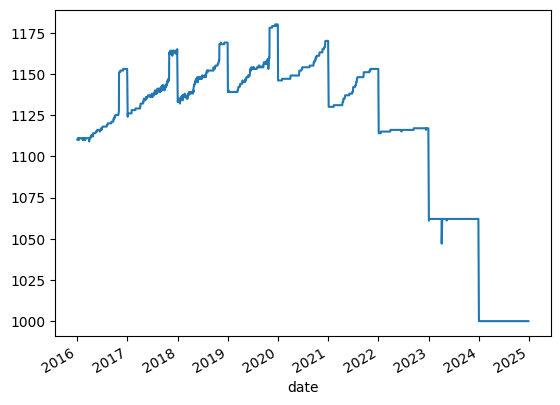

In [13]:
df[df['market_cap'].notna()].groupby('date').size().plot()

## Split to yearly universe data: previous 1 year + universe year

In [11]:
def get_monthly_factor_mining_data(
    df: pd.DataFrame,
    target_year: int,
    target_month: int,
    symbol_col: str = "instrument_id",
    time_col: str = "date",
    pool_dict: dict[int, list[int]] = None,
    lookback_months: int = 37,
    copy: bool = True,
) -> pd.DataFrame:

    if pool_dict is None:
        raise ValueError("pool_dict cannot be None.")

    if not 1 <= target_month <= 12:
        raise ValueError("target_month must be between 1 and 12.")

    if target_year not in pool_dict:
        raise ValueError(f"pool_dict does not contain target_year={target_year}.")

    # 假設 df[time_col] 已經是 datetime64
    target_month_start = pd.Timestamp(target_year, target_month, 1)
    start_date = target_month_start - pd.DateOffset(months=lookback_months)
    end_date = pd.Timestamp(target_year, 12, 31)

    id_set = set(pool_dict[target_year])

    mask = (
        df[time_col].between(start_date, end_date)
        & df[symbol_col].isin(id_set)
    )

    if copy:
        return df.loc[mask].copy()

    return df.loc[mask]

In [12]:
all_dfs = []

for y in range(OOS_START_YEAR, CUT_OUT_YEAR+1):
    df_tem = get_monthly_factor_mining_data(
        df=df,
        target_year=y,
        target_month=1,
        pool_dict=eligible_dict,
        lookback_months=12
    )
    all_dfs.append(df_tem)


In [13]:
import gc

for name in [
    "df", "df_tem"
]:
    if name in globals():
        del globals()[name]

gc.collect()

0

## Fill Market cap with CS median

In [14]:
def fill_market_cap_by_cross_section_median(
    all_dfs: list[pd.DataFrame],
    date_col: str = "date",
    value_col: str = "market_cap",
) -> tuple[list[pd.DataFrame], pd.DataFrame]:
    """
    For each dataframe in all_dfs:
    - identify dates with missing market_cap
    - fill missing market_cap by same-date cross-sectional median
    - return filled dataframes and missing-value report
    """

    filled_dfs = []
    report_rows = []

    for k, df in enumerate(all_dfs):
        out = df.copy()
        out[date_col] = pd.to_datetime(out[date_col])

        # before filling: missing count by date
        daily_missing = (
            out.groupby(date_col)[value_col]
            .agg(
                n_total="size",
                n_missing=lambda x: x.isna().sum(),
                n_available=lambda x: x.notna().sum(),
                cs_median="median",
            )
            .reset_index()
        )

        daily_missing["df_id"] = k
        daily_missing["has_missing"] = daily_missing["n_missing"] > 0

        report_rows.append(daily_missing)

        # same-date cross-sectional median
        cs_median_by_date = out.groupby(date_col)[value_col].transform("median")

        # fill missing market_cap with same-date median
        out[value_col] = out[value_col].fillna(cs_median_by_date)

        # safety check: if an entire date is missing, median is NaN and cannot be filled
        remaining_missing = out[value_col].isna().sum()
        if remaining_missing > 0:
            print(
                f"[Warning] dataframe {k}: still has {remaining_missing} missing "
                f"{value_col}. This means some dates have all values missing."
            )

        filled_dfs.append(out)

    missing_report = pd.concat(report_rows, ignore_index=True)

    return filled_dfs, missing_report

all_dfs, market_cap_missing_report = fill_market_cap_by_cross_section_median(
    all_dfs=all_dfs,
    date_col="date",
    value_col="market_cap",
)

## Feature Confirmation in Yearly Universe 
- For every CS in the previous 3 year, I want the NaN value of a feature < 50%
- If NaN > 50% for any CS in previous year, drop that feature

In [15]:
import pandas as pd
import numpy as np


def filter_features_by_training_year_missingness_fast(
    all_dfs: list[pd.DataFrame],
    universe_years: list[int],
    feature_groups: dict[str, list[str]],
    date_col: str = "date",
    missing_threshold: float = 0.50,
) -> tuple[list[pd.DataFrame], dict[int, list[str]], pd.DataFrame, pd.DataFrame]:

    if len(all_dfs) != len(universe_years):
        raise ValueError("len(all_dfs) must equal len(universe_years).")

    candidate_cols = [
        col
        for group_cols in feature_groups.values()
        for col in group_cols
    ]
    candidate_cols = list(dict.fromkeys(candidate_cols))

    all_dfs_filtered = []
    valid_feature_cols_by_year = {}
    dropped_rows = []
    daily_report_list = []

    for df_raw, universe_year in zip(all_dfs, universe_years):
        df = df_raw.copy()
        df[date_col] = pd.to_datetime(df[date_col])
        train_year = universe_year - 1

        train_df = df.loc[df[date_col] < pd.to_datetime(f'{universe_year}-01-01')].copy()

        if train_df.empty:
            raise ValueError(
                f"Universe year {universe_year}: no training-year data found for {train_year}."
            )

        check_cols = [c for c in candidate_cols if c in df.columns]

        # 一次性計算每日總筆數
        n_total_by_date = train_df.groupby(date_col).size()

        # 一次性計算所有 feature 每日 missing 數
        missing_counts = (
            train_df
            .groupby(date_col)[check_cols]
            .apply(lambda x: x.isna().sum())
        )

        # daily missing fraction: index=date, columns=features
        missing_frac = missing_counts.div(n_total_by_date, axis=0)

        # 每個 feature 的最大 daily missing fraction
        max_missing_frac = missing_frac.max(axis=0)

        # 是否要刪除
        dropped_cols = max_missing_frac[
            max_missing_frac > missing_threshold
        ].index.tolist()

        valid_cols = [
            c for c in check_cols
            if c not in dropped_cols
        ]

        # 建 dropped report
        for col in dropped_cols:
            worst_date = missing_frac[col].idxmax()
            n_total = int(n_total_by_date.loc[worst_date])
            n_missing = int(missing_counts.loc[worst_date, col])

            dropped_rows.append({
                "universe_year": universe_year,
                "train_year": train_year,
                "feature": col,
                "max_missing_frac": float(missing_frac.loc[worst_date, col]),
                "worst_date": worst_date,
                "n_total_on_worst_date": n_total,
                "n_missing_on_worst_date": n_missing,
                "n_available_on_worst_date": n_total - n_missing,
                "reason": f"daily missing fraction > {missing_threshold:.0%} in training year",
            })

        # 建 daily report，長表格式
        daily_report = (
            missing_frac
            .reset_index()
            .melt(
                id_vars=date_col,
                var_name="feature",
                value_name="missing_frac",
            )
        )
        daily_report["universe_year"] = universe_year
        daily_report["train_year"] = train_year

        daily_report_list.append(daily_report)

        # 從整個 previous-year + current-year df 刪掉 bad features
        df_filtered = df.drop(columns=dropped_cols, errors="ignore")

        all_dfs_filtered.append(df_filtered)
        valid_feature_cols_by_year[universe_year] = valid_cols

        print(
            f"Universe year {universe_year}: "
            f"checked {len(check_cols)} features, "
            f"kept {len(valid_cols)}, "
            f"dropped {len(dropped_cols)}."
        )

    dropped_feature_report = pd.DataFrame(dropped_rows)

    daily_missing_report = (
        pd.concat(daily_report_list, ignore_index=True)
        if daily_report_list
        else pd.DataFrame()
    )

    return (
        all_dfs_filtered,
        valid_feature_cols_by_year,
        dropped_feature_report,
        daily_missing_report,
    )

In [16]:
all_dfs_filtered, valid_feature_cols_by_year, dropped_feature_report, daily_missing_report = (
    filter_features_by_training_year_missingness_fast(
        all_dfs=all_dfs,
        universe_years=universe_years,
        feature_groups=feature_groups,
        date_col="date",
        missing_threshold=0.50,
    )
)

Universe year 2019: checked 250 features, kept 250, dropped 0.
Universe year 2020: checked 250 features, kept 250, dropped 0.
Universe year 2021: checked 250 features, kept 250, dropped 0.
Universe year 2022: checked 250 features, kept 250, dropped 0.
Universe year 2023: checked 250 features, kept 250, dropped 0.
Universe year 2024: checked 250 features, kept 250, dropped 0.


In [17]:
import json
from pathlib import Path

Path("processed").mkdir(parents=True, exist_ok=True)

valid_feature_cols_by_year_json = {
    str(year): cols
    for year, cols in valid_feature_cols_by_year.items()
}

with open("processed/valid_feature_cols_by_year.json", "w") as f:
    json.dump(valid_feature_cols_by_year_json, f, indent=4)

# Cut off Extreme Values
Using 5 MAD

In [18]:
import numpy as np
import pandas as pd


def median_mad_winsorize_cross_section_fast(
    df: pd.DataFrame,
    cols: list[str],
    date_col: str = "date",
    n_mad: float = 5.0,
) -> pd.DataFrame:
    """
    Cross-sectional median-MAD winsorization by date.

    For each date t and feature x:
        median_t = median_i(x_{i,t})
        mad_t    = median_i(|x_{i,t} - median_t|)
        lower_t  = median_t - n_mad * mad_t
        upper_t  = median_t + n_mad * mad_t

    Then clip each x_{i,t} into [lower_t, upper_t].

    If mad_t == 0 or NaN, the feature-date is left unchanged.
    """

    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col])

    cols = [c for c in cols if c in out.columns]

    if not cols:
        return out

    # Ensure numeric
    out[cols] = out[cols].apply(pd.to_numeric, errors="coerce")

    # Cross-sectional median by date
    cs_median = out.groupby(date_col)[cols].transform("median")

    # Cross-sectional MAD by date
    abs_dev = (out[cols] - cs_median).abs()
    cs_mad = abs_dev.groupby(out[date_col]).transform("median")

    lower = cs_median - n_mad * cs_mad
    upper = cs_median + n_mad * cs_mad

    # If MAD is 0 or NaN, do not clip that feature-date
    valid_mad = cs_mad.notna() & (cs_mad != 0)

    clipped = out[cols].clip(lower=lower, upper=upper, axis=0)

    out[cols] = out[cols].where(~valid_mad, clipped)

    return out

In [19]:
def winsorize_all_dfs_by_year(
    all_dfs: list[pd.DataFrame],
    universe_years: list[int],
    valid_feature_cols_by_year: dict[int, list[str]],
    date_col: str = "date",
    n_mad: float = 5.0,
) -> list[pd.DataFrame]:
    """
    Apply cross-sectional median-MAD winsorization to each yearly dataframe.

    Each dataframe uses that year's valid feature columns only.
    """

    if len(all_dfs) != len(universe_years):
        raise ValueError("len(all_dfs) must equal len(universe_years).")

    out_dfs = []

    for year, df_year in zip(universe_years, all_dfs):
        cols = valid_feature_cols_by_year[year]
        cols = [c for c in cols if c in df_year.columns]

        df_w = median_mad_winsorize_cross_section_fast(
            df=df_year,
            cols=cols,
            date_col=date_col,
            n_mad=n_mad,
        )

        out_dfs.append(df_w)

        print(
            f"Universe year {year}: winsorized {len(cols)} features "
            f"with {n_mad} MAD threshold."
        )

    return out_dfs

In [20]:
all_dfs_winsor = winsorize_all_dfs_by_year(
    all_dfs=all_dfs,
    universe_years=universe_years,
    valid_feature_cols_by_year=valid_feature_cols_by_year,
    date_col="date",
    n_mad=5.0,
)

Universe year 2019: winsorized 250 features with 5.0 MAD threshold.
Universe year 2020: winsorized 250 features with 5.0 MAD threshold.
Universe year 2021: winsorized 250 features with 5.0 MAD threshold.
Universe year 2022: winsorized 250 features with 5.0 MAD threshold.
Universe year 2023: winsorized 250 features with 5.0 MAD threshold.
Universe year 2024: winsorized 250 features with 5.0 MAD threshold.


In [21]:
def summarize_winsorization_changes(
    all_dfs_before: list[pd.DataFrame],
    all_dfs_after: list[pd.DataFrame],
    universe_years: list[int],
    valid_feature_cols_by_year: dict[int, list[str]],
) -> pd.DataFrame:
    rows = []

    for year, before, after in zip(universe_years, all_dfs_before, all_dfs_after):
        cols = [c for c in valid_feature_cols_by_year[year] if c in before.columns and c in after.columns]

        for col in cols:
            b = before[col]
            a = after[col]

            changed = b.notna() & a.notna() & (b != a)

            rows.append({
                "universe_year": year,
                "feature": col,
                "n_changed": int(changed.sum()),
                "changed_frac": float(changed.mean()),
            })

    return (
        pd.DataFrame(rows)
        .sort_values(["universe_year", "changed_frac"], ascending=[True, False])
        .reset_index(drop=True)
    )
winsor_change_report = summarize_winsorization_changes(
    all_dfs_before=all_dfs,
    all_dfs_after=all_dfs_winsor,
    universe_years=universe_years,
    valid_feature_cols_by_year=valid_feature_cols_by_year,
)

display(winsor_change_report.head(30))

,universe_year,feature,n_changed,changed_frac
0,2019,LINEARREG_SLOPE_volume_5,78391,0.155868
1,2019,LINEARREG_SLOPE_volume_21,76959,0.153020
2,2019,LINEARREG_SLOPE_volume_63,75062,0.149249
3,2019,LINEARREG_SLOPE_valuation_score_5,73430,0.146004
4,2019,LINEARREG_SLOPE_volume_252,71625,0.142415
5,2019,LINEARREG_SLOPE_quality_score_5,70905,0.140983
6,2019,LINEARREG_SLOPE_health_score_5,68227,0.135658
7,2019,estimate_turnover,65459,0.130155
8,2019,MIDPOINT_volume_252,63485,0.126230
9,2019,MIDPOINT_volume_63,63114,0.125492


In [22]:
import gc

for name in [
    "all_dfs"
]:
    if name in globals():
        del globals()[name]

gc.collect()

0

# Impute features by industry CS median

In [23]:
def impute_features_by_industry_median_cross_section_with_report(
    df: pd.DataFrame,
    feature_cols: list[str],
    date_col: str = "date",
    id_col: str = "instrument_id",
    industry_col: str = "gics_industry",
    fallback_value: float = 0.0,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Same-date same-industry median imputation with detailed report.

    Imputation hierarchy:
    1. same-date same-industry median
    2. same-date market median
    3. fallback_value
    """

    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col])

    if id_col not in out.columns:
        raise ValueError(f"{id_col} not found in df.")
    if industry_col not in out.columns:
        raise ValueError(f"{industry_col} not found in df.")

    feature_cols = [c for c in feature_cols if c in out.columns]

    if not feature_cols:
        raise ValueError("No valid feature columns found.")

    out[feature_cols] = out[feature_cols].apply(pd.to_numeric, errors="coerce")

    original_missing = out[feature_cols].isna()

    # -----------------------------
    # Same-date same-industry median
    # -----------------------------
    industry_median = (
        out.groupby([date_col, industry_col], observed=True)[feature_cols]
        .transform("median")
    )

    industry_available_count = (
        out.groupby([date_col, industry_col], observed=True)[feature_cols]
        .transform("count")
    )

    # -----------------------------
    # Same-date market median fallback
    # -----------------------------
    market_median = (
        out.groupby(date_col)[feature_cols]
        .transform("median")
    )

    market_available_count = (
        out.groupby(date_col)[feature_cols]
        .transform("count")
    )

    # -----------------------------
    # Decide imputation method
    # -----------------------------
    used_industry = original_missing & industry_median.notna()
    used_market = original_missing & industry_median.isna() & market_median.notna()
    used_fallback = original_missing & industry_median.isna() & market_median.isna()

    # -----------------------------
    # Fill values
    # -----------------------------
    out[feature_cols] = (
        out[feature_cols]
        .fillna(industry_median)
        .fillna(market_median)
        .fillna(fallback_value)
    )

    # -----------------------------
    # Build detailed long report
    # -----------------------------
    base_cols = [id_col, date_col, industry_col]

    report_frames = []

    for method_name, method_mask, value_source, n_ind_source, n_market_source in [
        (
            "industry_median",
            used_industry,
            industry_median,
            industry_available_count,
            market_available_count,
        ),
        (
            "market_median",
            used_market,
            market_median,
            industry_available_count,
            market_available_count,
        ),
        (
            "fallback_value",
            used_fallback,
            pd.DataFrame(
                fallback_value,
                index=out.index,
                columns=feature_cols,
            ),
            industry_available_count,
            market_available_count,
        ),
    ]:
        if not method_mask.to_numpy().any():
            continue

        mask_long = (
            method_mask
            .reset_index()
            .melt(
                id_vars="index",
                var_name="feature",
                value_name="was_imputed_by_method",
            )
        )

        mask_long = mask_long.loc[mask_long["was_imputed_by_method"]].copy()

        if mask_long.empty:
            continue

        value_long = (
            value_source
            .reset_index()
            .melt(
                id_vars="index",
                var_name="feature",
                value_name="imputed_value",
            )
        )

        n_ind_long = (
            n_ind_source
            .reset_index()
            .melt(
                id_vars="index",
                var_name="feature",
                value_name="n_available_same_industry",
            )
        )

        n_market_long = (
            n_market_source
            .reset_index()
            .melt(
                id_vars="index",
                var_name="feature",
                value_name="n_available_market",
            )
        )

        meta = out[base_cols].reset_index()

        temp_report = (
            mask_long[["index", "feature"]]
            .merge(meta, on="index", how="left")
            .merge(value_long, on=["index", "feature"], how="left")
            .merge(n_ind_long, on=["index", "feature"], how="left")
            .merge(n_market_long, on=["index", "feature"], how="left")
        )

        temp_report["impute_method"] = method_name

        report_frames.append(temp_report)

    if report_frames:
        impute_report = pd.concat(report_frames, ignore_index=True)
        impute_report = impute_report[
            [
                date_col,
                id_col,
                industry_col,
                "feature",
                "impute_method",
                "imputed_value",
                "n_available_same_industry",
                "n_available_market",
            ]
        ].sort_values([date_col, "feature", id_col])
    else:
        impute_report = pd.DataFrame(
            columns=[
                date_col,
                id_col,
                industry_col,
                "feature",
                "impute_method",
                "imputed_value",
                "n_available_same_industry",
                "n_available_market",
            ]
        )

    return out, impute_report

In [24]:
def impute_all_dfs_by_industry_median_with_report(
    all_dfs: list[pd.DataFrame],
    universe_years: list[int],
    valid_feature_cols_by_year: dict[int, list[str]],
    date_col: str = "date",
    id_col: str = "instrument_id",
    industry_col: str = "gics_industry",
    fallback_value: float = 0.0,
) -> tuple[list[pd.DataFrame], pd.DataFrame]:
    """
    Apply same-date same-industry median imputation to every yearly dataframe.
    Also return a detailed imputation report.
    """

    if len(all_dfs) != len(universe_years):
        raise ValueError("len(all_dfs) must equal len(universe_years).")

    out_dfs = []
    report_list = []

    for year, df_year in zip(universe_years, all_dfs):
        feature_cols = [
            c for c in valid_feature_cols_by_year[year]
            if c in df_year.columns
        ]

        df_imputed, impute_report_year = (
            impute_features_by_industry_median_cross_section_with_report(
                df=df_year,
                feature_cols=feature_cols,
                date_col=date_col,
                id_col=id_col,
                industry_col=industry_col,
                fallback_value=fallback_value,
            )
        )

        impute_report_year["universe_year"] = year

        n_missing_after = df_imputed[feature_cols].isna().sum().sum()
        n_imputed = len(impute_report_year)

        print(
            f"Universe year {year}: imputed {len(feature_cols)} features. "
            f"Total imputed cells = {n_imputed}. "
            f"Remaining missing = {n_missing_after}."
        )

        out_dfs.append(df_imputed)
        report_list.append(impute_report_year)

    impute_report = (
        pd.concat(report_list, ignore_index=True)
        if report_list
        else pd.DataFrame()
    )

    return out_dfs, impute_report

In [25]:
all_dfs_imputed, impute_report = impute_all_dfs_by_industry_median_with_report(
    all_dfs=all_dfs_winsor,
    universe_years=universe_years,
    valid_feature_cols_by_year=valid_feature_cols_by_year,
    date_col="date",
    id_col="instrument_id",
    industry_col="gics_industry",
    fallback_value=0.0,
)

Universe year 2019: imputed 250 features. Total imputed cells = 3751997. Remaining missing = 0.
Universe year 2020: imputed 250 features. Total imputed cells = 4030248. Remaining missing = 0.
Universe year 2021: imputed 250 features. Total imputed cells = 4740951. Remaining missing = 0.
Universe year 2022: imputed 250 features. Total imputed cells = 4711327. Remaining missing = 0.
Universe year 2023: imputed 250 features. Total imputed cells = 4410984. Remaining missing = 0.
Universe year 2024: imputed 250 features. Total imputed cells = 4623458. Remaining missing = 0.


In [26]:
impute_summary_by_year = (
    impute_report
    .groupby(["universe_year", "impute_method"])
    .size()
    .rename("n_imputed_cells")
    .reset_index()
)

display(impute_summary_by_year)

,universe_year,impute_method,n_imputed_cells
0,2019,industry_median,3751997
1,2020,industry_median,4030248
2,2021,industry_median,4740951
3,2022,industry_median,4686208
4,2022,market_median,25119
5,2023,industry_median,4380077
6,2023,market_median,30907
7,2024,fallback_value,5000
8,2024,industry_median,4569912
9,2024,market_median,48546


In [27]:
impute_summary_by_feature = (
    impute_report
    .groupby(["universe_year", "feature", "impute_method"])
    .size()
    .rename("n_imputed_cells")
    .reset_index()
    .sort_values(["universe_year", "n_imputed_cells"], ascending=[True, False])
)

display(impute_summary_by_feature.head(50))

,universe_year,feature,impute_method,n_imputed_cells
11,2019,DEMA_final_score_clean_252,industry_median,75636
7,2019,DEMA_final_score_252,industry_median,68202
23,2019,DEMA_momentum_score_252,industry_median,68158
15,2019,DEMA_health_score_252,industry_median,67819
29,2019,DEMA_quality_score_252,industry_median,67523
33,2019,DEMA_valuation_score_252,industry_median,67497
56,2019,KAMA_final_score_clean_252,industry_median,65322
13,2019,DEMA_final_score_clean_63,industry_median,62459
40,2019,HT_DCPHASE_final_score_clean,industry_median,61682
58,2019,KAMA_final_score_clean_63,industry_median,61682


In [28]:
import gc

for name in [
    "all_dfs_winsor"
]:
    if name in globals():
        del globals()[name]

gc.collect()

0

# Neutralization
- Typically, we expect that Log(Market Cap) and Industry has predictability
- We want to keep a feature's unexplained part, which is the OLS residual
- OLS: Feature = alpha + beta_1 * log(market cap) + beta_industry * industry_dummy_variable + residual
- Since there are no NaNs in Market cap or Industry, we can use the OLS to fill NaN

In [29]:
def neutralize_cross_section_multioutput_ols(
    df: pd.DataFrame,
    feature_cols: list[str],
    continuous_cols: list[str],
    categorical_cols: list[str],
    date_col: str = "date",
    market_cap_col: str = "market_cap",
    add_log_market_cap: bool = True,
    min_obs_buffer: int = 2,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Cross-sectional multi-output OLS neutralization.

    For each date:
        Y = X B + E

    Y contains all feature columns together.
    X contains intercept, continuous controls, and categorical dummies.
    Feature columns are replaced by residuals.
    """

    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col])

    if continuous_cols is None:
        continuous_cols = []

    if categorical_cols is None:
        categorical_cols = []

    if add_log_market_cap:
        if market_cap_col not in out.columns:
            raise ValueError(f"{market_cap_col} not found in df.")

        out["log_market_cap"] = np.log(
            pd.to_numeric(out[market_cap_col], errors="coerce")
        )

        if "log_market_cap" not in continuous_cols:
            continuous_cols = ["log_market_cap"] + continuous_cols

    feature_cols = [c for c in feature_cols if c in out.columns]
    continuous_cols = [c for c in continuous_cols if c in out.columns]
    categorical_cols = [c for c in categorical_cols if c in out.columns]

    if not feature_cols:
        raise ValueError("No valid feature columns found.")

    out[feature_cols] = out[feature_cols].apply(pd.to_numeric, errors="coerce")
    out[continuous_cols] = out[continuous_cols].apply(pd.to_numeric, errors="coerce")

    result_parts = []
    beta_records = []

    for dt, g in out.groupby(date_col, sort=True):
        g = g.copy()

        X_parts = [
            pd.DataFrame(
                {"intercept": np.ones(len(g), dtype=float)},
                index=g.index,
            )
        ]

        if continuous_cols:
            X_parts.append(g[continuous_cols].astype(float))

        if categorical_cols:
            cat_parts = []

            for cat_col in categorical_cols:
                dummies = pd.get_dummies(
                    g[cat_col].astype("category"),
                    prefix=cat_col,
                    drop_first=True,
                    dtype=float,
                )
                cat_parts.append(dummies)

            if cat_parts:
                X_parts.append(pd.concat(cat_parts, axis=1))

        X_df = pd.concat(X_parts, axis=1)
        x_names = X_df.columns.tolist()

        valid_x = X_df.notna().all(axis=1)

        X = X_df.loc[valid_x].to_numpy(dtype=float)
        Y = g.loc[valid_x, feature_cols].to_numpy(dtype=float)

        n_obs = X.shape[0]
        n_regressors = X.shape[1]
        min_obs = n_regressors + min_obs_buffer

        if n_obs < min_obs:
            Y_all = g[feature_cols].to_numpy(dtype=float)
            Y_dm = Y_all - np.nanmean(Y_all, axis=0, keepdims=True)
            Y_dm = np.nan_to_num(Y_dm, nan=0.0)

            g.loc[:, feature_cols] = Y_dm

            beta_records.append({
                date_col: pd.Timestamp(dt),
                "feature": "__ALL__",
                "x_col": "FALLBACK",
                "beta": np.nan,
                "n_obs": n_obs,
                "n_total": len(g),
                "note": "insufficient observations; demean fallback",
            })

            result_parts.append(g)
            continue

        try:
            B, *_ = np.linalg.lstsq(X, Y, rcond=None)

            Y_hat = X @ B
            Y_resid = Y - Y_hat

            g.loc[valid_x, feature_cols] = Y_resid

            if (~valid_x).any():
                g.loc[~valid_x, feature_cols] = 0.0

            # beta_df: long format
            for j, x_col in enumerate(x_names):
                for k, feature in enumerate(feature_cols):
                    beta_records.append({
                        date_col: pd.Timestamp(dt),
                        "feature": feature,
                        "x_col": x_col,
                        "beta": float(B[j, k]),
                        "n_obs": n_obs,
                        "n_total": len(g),
                        "note": "",
                    })

        except np.linalg.LinAlgError:
            Y_all = g[feature_cols].to_numpy(dtype=float)
            Y_dm = Y_all - np.nanmean(Y_all, axis=0, keepdims=True)
            Y_dm = np.nan_to_num(Y_dm, nan=0.0)

            g.loc[:, feature_cols] = Y_dm

            beta_records.append({
                date_col: pd.Timestamp(dt),
                "feature": "__ALL__",
                "x_col": "LINALG_ERROR",
                "beta": np.nan,
                "n_obs": n_obs,
                "n_total": len(g),
                "note": "lstsq failed; demean fallback",
            })

        result_parts.append(g)

    out_neu = pd.concat(result_parts, axis=0).sort_index()
    beta_df = pd.DataFrame(beta_records)

    return out_neu, beta_df

In [30]:
def neutralize_all_dfs_multioutput_ols(
    all_dfs_imputed: list[pd.DataFrame],
    universe_years: list[int],
    valid_feature_cols_by_year: dict[int, list[str]],
    continuous_cols: list[str],
    categorical_cols: list[str],
    date_col: str = "date",
    market_cap_col: str = "market_cap",
    add_log_market_cap: bool = True,
) -> tuple[list[pd.DataFrame], dict[int, pd.DataFrame]]:
    """
    Apply cross-sectional multi-output OLS neutralization to every yearly dataframe.
    """

    if len(all_dfs_imputed) != len(universe_years):
        raise ValueError("len(all_dfs_imputed) must equal len(universe_years).")

    out_dfs = []
    beta_by_year = {}

    for year, df_year in zip(universe_years, all_dfs_imputed):
        feature_cols = [
            c for c in valid_feature_cols_by_year[year]
            if c in df_year.columns
        ]

        df_neu, beta_df = neutralize_cross_section_multioutput_ols(
            df=df_year,
            feature_cols=feature_cols,
            continuous_cols=continuous_cols,
            categorical_cols=categorical_cols,
            date_col=date_col,
            market_cap_col=market_cap_col,
            add_log_market_cap=add_log_market_cap,
        )

        n_missing = df_neu[feature_cols].isna().sum().sum()

        print(
            f"Universe year {year}: neutralized {len(feature_cols)} features. "
            f"Remaining missing = {n_missing}."
        )

        out_dfs.append(df_neu)
        beta_by_year[year] = beta_df

    return out_dfs, beta_by_year

In [31]:
all_dfs_neu, beta_by_year = neutralize_all_dfs_multioutput_ols(
    all_dfs_imputed=all_dfs_imputed,
    universe_years=universe_years,
    valid_feature_cols_by_year=valid_feature_cols_by_year,
    continuous_cols=["log_market_cap"],
    categorical_cols=["gics_industry"],
    date_col="date",
    market_cap_col="market_cap",
    add_log_market_cap=True,
)

Universe year 2019: neutralized 250 features. Remaining missing = 0.
Universe year 2020: neutralized 250 features. Remaining missing = 0.
Universe year 2021: neutralized 250 features. Remaining missing = 0.
Universe year 2022: neutralized 250 features. Remaining missing = 0.
Universe year 2023: neutralized 250 features. Remaining missing = 0.
Universe year 2024: neutralized 250 features. Remaining missing = 0.


In [32]:
from pathlib import Path
import json
import pandas as pd

save_dir = Path("processed/all_dfs_neu")
save_dir.mkdir(parents=True, exist_ok=True)

universe_years = list(range(OOS_START_YEAR, CUT_OUT_YEAR+1))

for year, df_year in zip(universe_years, all_dfs_neu):
    path = save_dir / f"universe_{year}_neutralized.parquet"
    df_year.to_parquet(path, index=False)
    print(f"Saved {year}: {path}, shape={df_year.shape}")

metadata = {
    "universe_years": universe_years,
    "description": "Neutralized and imputed yearly universe dataframes",
}

with open(save_dir / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

Saved 2019: processed/all_dfs_neu/universe_2019_neutralized.parquet, shape=(502933, 256)
Saved 2020: processed/all_dfs_neu/universe_2020_neutralized.parquet, shape=(504989, 256)
Saved 2021: processed/all_dfs_neu/universe_2021_neutralized.parquet, shape=(505000, 256)
Saved 2022: processed/all_dfs_neu/universe_2022_neutralized.parquet, shape=(502999, 256)
Saved 2023: processed/all_dfs_neu/universe_2023_neutralized.parquet, shape=(500984, 256)
Saved 2024: processed/all_dfs_neu/universe_2024_neutralized.parquet, shape=(499986, 256)


In [33]:
import gc

for name in [
    "all_dfs_imputed"
]:
    if name in globals():
        del globals()[name]

gc.collect()

33

In [ ]:
# from pathlib import Path
# import json
# import pandas as pd
# import json

# with open("processed/valid_feature_cols_by_year.json", "r") as f:
#     valid_feature_cols_by_year_loaded = json.load(f)

# # 把 key 轉回 int
# valid_feature_cols_by_year_loaded = {
#     int(year): cols
#     for year, cols in valid_feature_cols_by_year_loaded.items()
# }
# save_dir = Path("processed/all_dfs_neu")

# with open(save_dir / "metadata.json", "r") as f:
#     metadata = json.load(f)


# universe_years = metadata["universe_years"]

# all_dfs_neu = []

# for year in universe_years:
#     path = save_dir / f"universe_{year}_neutralized.parquet"
#     df_year = pd.read_parquet(path)
#     df_year["date"] = pd.to_datetime(df_year["date"])
#     all_dfs_neu.append(df_year)

#     print(f"Loaded {year}: shape={df_year.shape}")

Loaded 2019: shape=(997322, 93)
Loaded 2020: shape=(998188, 93)
Loaded 2021: shape=(998300, 93)
Loaded 2022: shape=(996981, 93)
Loaded 2023: shape=(996175, 93)
Loaded 2024: shape=(999022, 93)


# Standarization

In [34]:
def zscore_standardize_cross_section_fast(
    df: pd.DataFrame,
    cols: list[str],
    date_col: str = "date",
    ddof: int = 0,
    fill_zero_if_constant: bool = True,
) -> pd.DataFrame:
    """
    Cross-sectional z-score standardization by date.

    For each date t and feature k:
        z_{i,t,k} = (x_{i,t,k} - mean_{t,k}) / std_{t,k}

    If std is 0 or NaN:
        - fill_zero_if_constant=True: set z-score to 0
        - otherwise: set z-score to NaN

    This function is vectorized across columns.
    """

    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col])

    cols = [c for c in cols if c in out.columns]

    if not cols:
        return out

    out[cols] = out[cols].apply(pd.to_numeric, errors="coerce")

    cs_mean = out.groupby(date_col)[cols].transform("mean")
    cs_std = out.groupby(date_col)[cols].transform(lambda x: x.std(ddof=ddof))

    z = (out[cols] - cs_mean) / cs_std

    invalid_std = cs_std.isna() | (cs_std == 0)

    if fill_zero_if_constant:
        z = z.mask(invalid_std, 0.0)
    else:
        z = z.mask(invalid_std, np.nan)

    out[cols] = z

    return out

In [35]:
def zscore_all_dfs_by_year(
    all_dfs_neu: list[pd.DataFrame],
    universe_years: list[int],
    valid_feature_cols_by_year: dict[int, list[str]],
    date_col: str = "date",
    ddof: int = 0,
    fill_zero_if_constant: bool = True,
) -> list[pd.DataFrame]:
    """
    Apply cross-sectional z-score standardization to every yearly universe dataframe.

    Each year's dataframe uses only that year's valid features.
    """

    if len(all_dfs_neu) != len(universe_years):
        raise ValueError("len(all_dfs_neu) must equal len(universe_years).")

    out_dfs = []

    for year, df_year in zip(universe_years, all_dfs_neu):
        feature_cols = [
            c for c in valid_feature_cols_by_year[year]
            if c in df_year.columns
        ]

        df_z = zscore_standardize_cross_section_fast(
            df=df_year,
            cols=feature_cols,
            date_col=date_col,
            ddof=ddof,
            fill_zero_if_constant=fill_zero_if_constant,
        )

        out_dfs.append(df_z)

        n_missing = df_z[feature_cols].isna().sum().sum()

        print(
            f"Universe year {year}: standardized {len(feature_cols)} features. "
            f"Remaining missing = {n_missing}."
        )

    return out_dfs

In [36]:
all_dfs_z = zscore_all_dfs_by_year(
    all_dfs_neu=all_dfs_neu,
    universe_years=universe_years,
    valid_feature_cols_by_year=valid_feature_cols_by_year,
    date_col="date",
    ddof=0,
    fill_zero_if_constant=True,
)

Universe year 2019: standardized 250 features. Remaining missing = 0.
Universe year 2020: standardized 250 features. Remaining missing = 0.
Universe year 2021: standardized 250 features. Remaining missing = 0.
Universe year 2022: standardized 250 features. Remaining missing = 0.
Universe year 2023: standardized 250 features. Remaining missing = 0.
Universe year 2024: standardized 250 features. Remaining missing = 0.


In [37]:
import gc

for name in [
    "all_dfs_neu"
]:
    if name in globals():
        del globals()[name]

gc.collect()

0

In [38]:
from pathlib import Path
import json
import pandas as pd

save_dir = Path("processed/all_dfs_z")
save_dir.mkdir(parents=True, exist_ok=True)

universe_years = list(range(OOS_START_YEAR, CUT_OUT_YEAR+1))

for year, df_year in zip(universe_years, all_dfs_z):
    path = save_dir / f"universe_{year}_z.parquet"
    df_year.to_parquet(path, index=False)
    print(f"Saved {year}: {path}, shape={df_year.shape}")

metadata = {
    "universe_years": universe_years,
    "description": "Neutralized and imputed yearly universe dataframes",
}

with open(save_dir / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

Saved 2019: processed/all_dfs_z/universe_2019_z.parquet, shape=(502933, 256)
Saved 2020: processed/all_dfs_z/universe_2020_z.parquet, shape=(504989, 256)
Saved 2021: processed/all_dfs_z/universe_2021_z.parquet, shape=(505000, 256)
Saved 2022: processed/all_dfs_z/universe_2022_z.parquet, shape=(502999, 256)
Saved 2023: processed/all_dfs_z/universe_2023_z.parquet, shape=(500984, 256)
Saved 2024: processed/all_dfs_z/universe_2024_z.parquet, shape=(499986, 256)


In [39]:
from pathlib import Path
import json
import pandas as pd

save_dir = Path("processed/all_dfs_z")

with open(save_dir / "metadata.json", "r") as f:
    metadata = json.load(f)


universe_years = metadata["universe_years"]

all_dfs_z = []

for year in universe_years:
    path = save_dir / f"universe_{year}_z.parquet"
    df_year = pd.read_parquet(path)
    df_year["date"] = pd.to_datetime(df_year["date"])
    all_dfs_z.append(df_year)

    print(f"Loaded {year}: shape={df_year.shape}")





Loaded 2019: shape=(997322, 93)
Loaded 2020: shape=(998188, 93)
Loaded 2021: shape=(998300, 93)
Loaded 2022: shape=(996981, 93)
Loaded 2023: shape=(996175, 93)
Loaded 2024: shape=(999022, 93)


In [39]:
def check_zscore_by_year(
    all_dfs_z: list[pd.DataFrame],
    universe_years: list[int],
    valid_feature_cols_by_year: dict[int, list[str]],
    date_col: str = "date",
) -> pd.DataFrame:
    rows = []

    for year, df_year in zip(universe_years, all_dfs_z):
        df = df_year.copy()
        df[date_col] = pd.to_datetime(df[date_col])

        cols = [c for c in valid_feature_cols_by_year[year] if c in df.columns]

        daily_mean = df.groupby(date_col)[cols].mean()
        daily_std = df.groupby(date_col)[cols].std(ddof=0)

        rows.append({
            "universe_year": year,
            "max_abs_daily_mean": daily_mean.abs().max().max(),
            "median_daily_std": daily_std.median().median(),
            "min_daily_std": daily_std.min().min(),
            "max_daily_std": daily_std.max().max(),
            "n_missing": df[cols].isna().sum().sum(),
        })

    return pd.DataFrame(rows)


zscore_check = check_zscore_by_year(
    all_dfs_z=all_dfs_z,
    universe_years=universe_years,
    valid_feature_cols_by_year=valid_feature_cols_by_year,
    date_col="date",
)

display(zscore_check)

,universe_year,max_abs_daily_mean,median_daily_std,min_daily_std,max_daily_std,n_missing
0,2019,5.001555e-17,1.0,1.0,1.0,0
1,2020,5.023759e-17,1.0,1.0,1.0,0
2,2021,4.840572e-17,1.0,1.0,1.0,0
3,2022,4.515832e-17,1.0,1.0,1.0,0
4,2023,4.973799e-17,1.0,1.0,1.0,0
5,2024,4.751755e-17,1.0,0.0,1.0,0


## Merge with SP500 return

In [40]:
all_dfs_z = [
    df.assign(date=pd.to_datetime(df["date"])).merge(
        sp500,
        on="date",
        how="left",
        validate="m:1",
    )
    for df in all_dfs_z
]

# Section 5
# Model Pipeline

**For each prediction month:**

past 12 months  

→ first 10 months: label top/bottom \(n\%\) returns and train classifier  

→ validation 2 months: predict scores  

→ use validation no-cost portfolio return / Sharpe / IC / ICIR to select hyperparameters  

→ refit on full 12 months using top/bottom \(n\%\) labels  

→ predict next month  

→ output `predictions_*` with model scores  

→ formal backtest with eligibility filters, trading costs, slippage, and borrow costs  

In [41]:
import numpy as np
import pandas as pd

from sklearn.linear_model import SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import ParameterGrid
from sklearn.base import clone
from sklearn.linear_model import ElasticNet

from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt



from sklearn.model_selection import ParameterGrid
from sklearn.base import clone


Python(30159) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


## Generate Label

In [42]:
def make_cross_section_extreme_labels(
    df: pd.DataFrame,
    target_col: str = "target_c2o_next_adj",
    date_col: str = "date",
    label_pct: float = 0.30,
    out_col: str = "target_label",
) -> pd.DataFrame:
    """
    For each date:
        top label_pct by target return -> +1
        bottom label_pct by target return -> -1
        middle -> 0

    Training later uses only +1 and -1.
    """

    if not (0 < label_pct < 0.5):
        raise ValueError("label_pct must be between 0 and 0.5.")

    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col])
    out[target_col] = pd.to_numeric(out[target_col], errors="coerce")

    out[out_col] = 0

    valid = out[target_col].notna()

    # Rank return within each date.
    # rank_pct_high close to 1 = high return.
    rank_pct_high = (
        out.loc[valid]
        .groupby(date_col)[target_col]
        .rank(method="first", pct=True, ascending=True)
    )

    out.loc[valid & (rank_pct_high >= 1.0 - label_pct), out_col] = 1
    out.loc[valid & (rank_pct_high <= label_pct), out_col] = -1

    return out

## Get Classifier Score

In [19]:
def get_classifier_score(
    model,
    X: np.ndarray,
    positive_class: int = 1,
    negative_class: int = -1,
) -> np.ndarray:
    """
    Convert classifier output into a continuous score.

    Preferred:
        score = P(y=+1) - P(y=-1)

    Fallback:
        decision_function or predict.
    """

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        classes = list(model.classes_)

        score = np.zeros(X.shape[0], dtype=float)

        if positive_class in classes:
            pos_idx = classes.index(positive_class)
            score += proba[:, pos_idx]

        if negative_class in classes:
            neg_idx = classes.index(negative_class)
            score -= proba[:, neg_idx]

        return score

    if hasattr(model, "decision_function"):
        score = model.decision_function(X)

        if np.ndim(score) == 2:
            classes = list(model.classes_)
            out = np.zeros(X.shape[0], dtype=float)

            if positive_class in classes:
                out += score[:, classes.index(positive_class)]

            if negative_class in classes:
                out -= score[:, classes.index(negative_class)]

            return out

        return score.astype(float)

    return model.predict(X).astype(float)

## Build Return from Scores

In [14]:
def build_no_cost_daily_return_from_scores(
    df: pd.DataFrame,
    score_col: str = "score",
    return_col: str = "target_c2o_next_adj",
    date_col: str = "date",
    id_col: str = "instrument_id",
    trade_pct: float = 0.10,
    min_names: int = 30,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Build no-cost daily long-short returns from model scores.

    For each date:
        top trade_pct by score -> long
        bottom trade_pct by score -> short

    Return:
        long_return = mean(raw return of long names)
        short_return = mean(-raw return of short names)
        portfolio_return = 0.5 * long_return + 0.5 * short_return
    """

    if not (0 < trade_pct < 0.5):
        raise ValueError("trade_pct must be between 0 and 0.5.")

    temp = df[[date_col, id_col, score_col, return_col]].copy()
    temp[date_col] = pd.to_datetime(temp[date_col])
    temp[score_col] = pd.to_numeric(temp[score_col], errors="coerce")
    temp[return_col] = pd.to_numeric(temp[return_col], errors="coerce")

    temp = temp.dropna(subset=[score_col, return_col]).copy()

    if temp.empty:
        return pd.DataFrame(), pd.DataFrame()

    temp["n_names"] = temp.groupby(date_col)[id_col].transform("count")
    temp = temp.loc[temp["n_names"] >= min_names].copy()

    if temp.empty:
        return pd.DataFrame(), pd.DataFrame()

    rank_high = temp.groupby(date_col)[score_col].rank(method="first", pct=True, ascending=True)

    temp["side"] = 0
    temp.loc[rank_high >= 1.0 - trade_pct, "side"] = 1
    temp.loc[rank_high <= trade_pct, "side"] = -1

    position_df = temp.loc[temp["side"].ne(0)].copy()

    position_df["stock_return_gross"] = np.where(
        position_df["side"].eq(1),
        position_df[return_col],
        -position_df[return_col],
    )

    long_daily = (
        position_df.loc[position_df["side"].eq(1)]
        .groupby(date_col)
        .agg(
            long_return=("stock_return_gross", "mean"),
            n_long_actual=(id_col, "count"),
        )
    )

    short_daily = (
        position_df.loc[position_df["side"].eq(-1)]
        .groupby(date_col)
        .agg(
            short_return=("stock_return_gross", "mean"),
            n_short_actual=(id_col, "count"),
        )
    )

    daily_return_df = (
        long_daily
        .join(short_daily, how="inner")
        .sort_index()
        .reset_index()
    )

    daily_return_df["portfolio_return"] = (
        0.5 * daily_return_df["long_return"]
        + 0.5 * daily_return_df["short_return"]
    )

    daily_return_df["cum_return_simple"] = daily_return_df["portfolio_return"].fillna(0.0).cumsum()

    return daily_return_df, position_df

## Validation Metrics 
return / sharpe / ic / icir

In [12]:
def summarize_daily_return(
    daily_return_df: pd.DataFrame,
    return_col: str = "portfolio_return",
    periods_per_year: int = 252,
) -> dict:
    r = pd.to_numeric(daily_return_df[return_col], errors="coerce").dropna()

    if r.empty:
        return {
            "mean_daily_return": np.nan,
            "total_return_simple": np.nan,
            "annualized_return": np.nan,
            "annualized_volatility": np.nan,
            "sharpe": np.nan,
            "n_return_days": 0,
        }

    ann_return = r.mean() * periods_per_year
    ann_vol = r.std(ddof=1) * np.sqrt(periods_per_year)

    sharpe = np.nan
    if pd.notna(ann_vol) and ann_vol != 0:
        sharpe = ann_return / ann_vol

    return {
        "mean_daily_return": r.mean(),
        "total_return_simple": r.sum(),
        "annualized_return": ann_return,
        "annualized_volatility": ann_vol,
        "sharpe": sharpe,
        "n_return_days": len(r),
    }


def evaluate_validation_scores(
    val_eval: pd.DataFrame,
    score_col: str = "score",
    target_col: str = "target_c2o_next_adj",
    date_col: str = "date",
    id_col: str = "instrument_id",
    trade_pct: float = 0.10,
    min_ic_names: int = 30,
    periods_per_year: int = 252,
) -> dict:
    """
    Evaluate model score on validation set by:
    1. no-cost long-short return
    2. daily Spearman IC
    """

    daily_ret, position_df = build_no_cost_daily_return_from_scores(
        df=val_eval,
        score_col=score_col,
        return_col=target_col,
        date_col=date_col,
        id_col=id_col,
        trade_pct=trade_pct,
        min_names=min_ic_names,
    )

    ret_summary = summarize_daily_return(
        daily_return_df=daily_ret,
        return_col="portfolio_return",
        periods_per_year=periods_per_year,
    )

    ic = daily_spearman_ic_fast(
        df=val_eval,
        score_col=score_col,
        target_col=target_col,
        date_col=date_col,
        min_names=min_ic_names,
    )

    ic_summary = summarize_ic(ic)

    icir = np.nan
    if pd.notna(ic_summary["ic_std"]) and ic_summary["ic_std"] != 0:
        icir = ic_summary["ic_mean"] / ic_summary["ic_std"]

    out = {
        "val_mean_daily_return": ret_summary["mean_daily_return"],
        "val_total_return_simple": ret_summary["total_return_simple"],
        "val_annualized_return": ret_summary["annualized_return"],
        "val_annualized_volatility": ret_summary["annualized_volatility"],
        "val_sharpe": ret_summary["sharpe"],
        "val_n_return_days": ret_summary["n_return_days"],
        "val_ic_mean": ic_summary["ic_mean"],
        "val_ic_std": ic_summary["ic_std"],
        "val_ic_tstat": ic_summary["ic_tstat"],
        "val_icir": icir,
        "val_n_ic_days": ic_summary["n_days"],
    }

    return out


def get_selection_score(
    metrics: dict,
    selection_metric: str = "sharpe",
) -> float:
    """
    selection_metric can be:
        'return'  -> validation total simple return
        'abs_return' -> absolute validation total simple return
        'sharpe'  -> validation Sharpe
        'ic'      -> validation mean IC
        'icir'    -> validation ICIR
    """

    if selection_metric == "return":
        return metrics.get("val_total_return_simple", np.nan)

    if selection_metric == "abs_return":
        x = metrics.get("val_total_return_simple", np.nan)
        return abs(x) if pd.notna(x) else np.nan

    if selection_metric == "sharpe":
        return metrics.get("val_sharpe", np.nan)

    if selection_metric == "ic":
        return metrics.get("val_ic_mean", np.nan)

    if selection_metric == "icir":
        return metrics.get("val_icir", np.nan)

    raise ValueError(
        "selection_metric must be one of: "
        "'return', 'abs_return', 'sharpe', 'ic', 'icir'."
    )

## Generic classifier one-window framework

In [18]:
def build_spearman_feature_clusters(
    df: pd.DataFrame,
    feature_cols: list[str],
    corr_threshold: float = 0.70,
) -> list[list[str]]:
    """
    Build greedy Spearman-correlation clusters.

    Each cluster is constrained so every feature has absolute Spearman correlation
    greater than corr_threshold with every other feature already in that cluster.
    """

    feature_cols = [c for c in feature_cols if c in df.columns]

    if not feature_cols:
        return []

    if len(feature_cols) == 1:
        return [[feature_cols[0]]]

    corr = (
        df[feature_cols]
        .corr(method="spearman")
        .abs()
        .reindex(index=feature_cols, columns=feature_cols)
        .fillna(0.0)
    )
    np.fill_diagonal(corr.values, 1.0)

    remaining = feature_cols.copy()
    clusters = []

    while remaining:
        seed = max(
            remaining,
            key=lambda c: corr.loc[c, remaining].mean(),
        )
        cluster = [seed]
        remaining.remove(seed)

        while True:
            candidates = [
                c for c in remaining
                if (corr.loc[c, cluster] > corr_threshold).all()
            ]

            if not candidates:
                break

            best_candidate = max(
                candidates,
                key=lambda c: (corr.loc[c, cluster].min(), corr.loc[c, cluster].mean()),
            )
            cluster.append(best_candidate)
            remaining.remove(best_candidate)

        clusters.append(cluster)

    return clusters


def compute_cluster_permutation_importance(
    model,
    X_val: np.ndarray,
    y_val: np.ndarray,
    feature_cols: list[str],
    feature_clusters: list[list[str]],
    scoring: str = "balanced_accuracy",
    n_repeats: int = 3,
    random_state: int = 2026,
) -> pd.DataFrame:
    """
    Compute cluster permutation importance by shuffling all features in one cluster together.
    """

    from sklearn.metrics import get_scorer

    scorer = get_scorer(scoring)
    baseline_score = scorer(model, X_val, y_val)
    rng = np.random.default_rng(random_state)
    feature_pos = {feature: i for i, feature in enumerate(feature_cols)}
    rows = []

    for cluster_id, cluster_features in enumerate(feature_clusters):
        cluster_indices = [feature_pos[f] for f in cluster_features]
        repeat_importances = []
        repeat_scores = []

        for _ in range(n_repeats):
            X_perm = X_val.copy()
            shuffled_rows = rng.permutation(X_perm.shape[0])
            X_perm[:, cluster_indices] = X_perm[shuffled_rows][:, cluster_indices]

            permuted_score = scorer(model, X_perm, y_val)
            repeat_scores.append(permuted_score)
            repeat_importances.append(baseline_score - permuted_score)

        rows.append({
            "cluster_id": cluster_id,
            "features": cluster_features,
            "n_features": len(cluster_features),
            "baseline_score": baseline_score,
            "permuted_score_mean": float(np.mean(repeat_scores)),
            "cluster_permutation_importance_mean": float(np.mean(repeat_importances)),
            "cluster_permutation_importance_std": float(np.std(repeat_importances, ddof=1)) if n_repeats > 1 else 0.0,
        })

    return pd.DataFrame(rows).sort_values(
        "cluster_permutation_importance_mean",
        ascending=False,
    )


def fit_cluster_pca_transformers(
    df_fit: pd.DataFrame,
    feature_clusters: list[list[str]],
) -> tuple[list[dict], list[str], pd.DataFrame]:
    """
    Fit one StandardScaler + PC1 transformer per feature cluster.
    """

    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler

    transformers = []
    pca_feature_cols = []
    metadata_rows = []

    for cluster_id, cluster_features in enumerate(feature_clusters):
        pca_col = f"cluster_{cluster_id:03d}_pc1"
        scaler = StandardScaler()
        pca = PCA(n_components=1)

        X_fit = df_fit[cluster_features].to_numpy(dtype=float)
        X_fit_scaled = scaler.fit_transform(X_fit)
        pca.fit(X_fit_scaled)

        transformers.append({
            "cluster_id": cluster_id,
            "features": cluster_features,
            "pca_feature": pca_col,
            "scaler": scaler,
            "pca": pca,
        })
        pca_feature_cols.append(pca_col)
        metadata_rows.append({
            "cluster_id": cluster_id,
            "pca_feature": pca_col,
            "features": cluster_features,
            "n_features": len(cluster_features),
            "explained_variance_ratio_pc1": float(pca.explained_variance_ratio_[0]),
        })

    return transformers, pca_feature_cols, pd.DataFrame(metadata_rows)


def transform_cluster_pca_features(
    df: pd.DataFrame,
    transformers: list[dict],
) -> np.ndarray:
    """
    Apply fitted cluster PCA transformers and return one matrix with one column per cluster.
    """

    transformed_cols = []

    for transformer in transformers:
        cluster_features = transformer["features"]
        scaler = transformer["scaler"]
        pca = transformer["pca"]

        X = df[cluster_features].to_numpy(dtype=float)
        X_scaled = scaler.transform(X)
        transformed_cols.append(pca.transform(X_scaled).reshape(-1))

    if not transformed_cols:
        return np.empty((len(df), 0))

    return np.column_stack(transformed_cols)


def fit_select_refit_predict_classifier_one_window(
    df_window: pd.DataFrame,
    df_predict: pd.DataFrame,
    feature_cols: list[str],
    model_factory,
    param_grid: dict,
    model_name: str,
    label_pct: float = 0.10,
    trade_pct: float = 0.10,
    selection_metric: str = "sharpe",
    target_col_raw: str = "target_c2o_next_adj",
    label_col: str = "target_label",
    date_col: str = "date",
    id_col: str = "instrument_id",
    eligibility_col = "is_eligible",
    whole_train_days: int = 60,
    val_days: int = 10,
    use_permutation_feature_filter: bool = False,
    permutation_filter_model_factory = None,
    permutation_filter_params: dict = None,
    permutation_filter_scoring: str = "balanced_accuracy",
    permutation_filter_n_repeats: int = 3,
    permutation_filter_random_state: int = 2026,
    permutation_filter_min_features: int = 5,
    permutation_cluster_corr_threshold: float = 0.70,
    use_cluster_pca_features: bool = False,
    min_train_obs: int = 500,
    min_val_obs: int = 200,
    min_ic_names: int = 30,
    periods_per_year: int = 252,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Generic classification rolling-window framework.

    Optional first step:
    1. Label the full train+validation window.
    2. Build Spearman correlation clusters on the training portion.
    3. Train a simple model on the training portion.
    4. Compute cluster permutation importance on labelled validation samples.
    5. Remove clusters with negative permutation importance.
    6. Optionally compress each kept cluster into one PC1 feature.

    Then run the normal workflow:
    1. Train candidate models on the filtered/PCA training window.
    2. Select hyperparameters by validation Sharpe / IC metric.
    3. Refit best model on the full train+validation window.
    4. Predict the next prediction window.
    """

    df_window = df_window.copy()
    df_predict = df_predict.copy()

    df_window[date_col] = pd.to_datetime(df_window[date_col])
    df_predict[date_col] = pd.to_datetime(df_predict[date_col])

    if eligibility_col is not None and eligibility_col in df_window.columns:
        df_window = df_window.loc[df_window[eligibility_col].astype(bool)].copy()

    if eligibility_col is not None and eligibility_col in df_predict.columns:
        df_predict = df_predict.loc[df_predict[eligibility_col].astype(bool)].copy()

    if df_window.empty or df_predict.empty:
        return pd.DataFrame(), pd.DataFrame()

    # Drop last training-window date to avoid target availability leakage.
    last_window_date = df_window[date_col].max()
    df_window = df_window.loc[df_window[date_col] < last_window_date].copy()

    if df_window.empty:
        return pd.DataFrame(), pd.DataFrame()

    feature_cols = [
        c for c in feature_cols
        if c in df_window.columns and c in df_predict.columns
    ]

    if not feature_cols:
        return pd.DataFrame(), pd.DataFrame()

    df_window = df_window.dropna(subset=feature_cols + [target_col_raw]).copy()
    df_predict = df_predict.dropna(subset=feature_cols).copy()

    if df_window.empty or df_predict.empty:
        return pd.DataFrame(), pd.DataFrame()

    if val_days <= 0 or whole_train_days <= val_days:
        raise ValueError("whole_train_days must be greater than val_days, and val_days must be positive.")

    train_days = whole_train_days - val_days
    window_dates = pd.Index(pd.to_datetime(df_window[date_col].drop_duplicates()).sort_values())

    if len(window_dates) < whole_train_days:
        diagnostics = pd.DataFrame([{
            "model_name": model_name,
            "status": "skipped_insufficient_unique_train_days",
            "n_trainval_days": len(window_dates),
            "whole_train_days": whole_train_days,
            "train_days": train_days,
            "val_days": val_days,
            "n_features_before_filter": len(feature_cols),
            "n_features_after_filter": len(feature_cols),
            "permutation_filter_used": use_permutation_feature_filter,
        }])
        return pd.DataFrame(), diagnostics

    val_start = window_dates[-val_days]

    train_df = df_window.loc[df_window[date_col] < val_start].copy()
    val_df = df_window.loc[df_window[date_col] >= val_start].copy()

    if len(train_df) < min_train_obs or len(val_df) < min_val_obs:
        diagnostics = pd.DataFrame([{
            "model_name": model_name,
            "status": "skipped_insufficient_data",
            "n_train_raw": len(train_df),
            "n_val": len(val_df),
            "best_params": None,
            "whole_train_days": whole_train_days,
            "train_days": train_days,
            "val_days": val_days,
            "n_features_before_filter": len(feature_cols),
            "n_features_after_filter": len(feature_cols),
            "permutation_filter_used": use_permutation_feature_filter,
        }])
        return pd.DataFrame(), diagnostics

    # Label the full train+validation window so the permutation step can use labelled validation rows.
    labelled_window = make_cross_section_extreme_labels(
        df=df_window,
        target_col=target_col_raw,
        date_col=date_col,
        label_pct=label_pct,
        out_col=label_col,
    )

    train_df = labelled_window.loc[labelled_window[date_col] < val_start].copy()
    val_df = labelled_window.loc[labelled_window[date_col] >= val_start].copy()

    train_labeled = train_df.loc[train_df[label_col].isin([-1, 1])].copy()
    val_labeled_for_filter = val_df.loc[val_df[label_col].isin([-1, 1])].copy()

    if len(train_labeled) < min_train_obs:
        diagnostics = pd.DataFrame([{
            "model_name": model_name,
            "status": "skipped_insufficient_labelled_train_data",
            "n_train_raw": len(train_df),
            "n_train_labeled": len(train_labeled),
            "n_val": len(val_df),
            "best_params": None,
            "whole_train_days": whole_train_days,
            "train_days": train_days,
            "val_days": val_days,
            "n_features_before_filter": len(feature_cols),
            "n_features_after_filter": len(feature_cols),
            "permutation_filter_used": use_permutation_feature_filter,
        }])
        return pd.DataFrame(), diagnostics

    feature_cols_before_filter = feature_cols.copy()
    permutation_filter_status = "not_used"
    permutation_removed_features = []
    permutation_removed_clusters = []
    feature_clusters_after_filter = []
    permutation_importance_table = pd.DataFrame()
    pca_metadata = pd.DataFrame()
    pca_feature_cols = []
    n_permutation_clusters_before_filter = 0
    n_permutation_clusters_after_filter = 0
    n_permutation_clusters_removed = 0
    max_permutation_cluster_size = 0

    if use_permutation_feature_filter:
        filter_factory = permutation_filter_model_factory or model_factory
        filter_params = permutation_filter_params or {}

        filter_train = train_labeled.dropna(subset=feature_cols + [label_col]).copy()
        filter_val = val_labeled_for_filter.dropna(subset=feature_cols + [label_col]).copy()

        if len(filter_train) < min_train_obs or len(filter_val) < min_val_obs:
            permutation_filter_status = "skipped_insufficient_labelled_validation_data"
        else:
            try:
                feature_clusters = build_spearman_feature_clusters(
                    df=filter_train,
                    feature_cols=feature_cols,
                    corr_threshold=permutation_cluster_corr_threshold,
                )
                n_permutation_clusters_before_filter = len(feature_clusters)
                max_permutation_cluster_size = max((len(cluster) for cluster in feature_clusters), default=0)

                print(
                    f"{model_name} {df_predict[date_col].min():%Y-%m}: "
                    f"clustered {len(feature_cols)} features into {n_permutation_clusters_before_filter} groups; "
                    f"largest group has {max_permutation_cluster_size} features "
                    f"(abs Spearman > {permutation_cluster_corr_threshold})."
                )

                basic_model = filter_factory(filter_params)
                X_filter_train = filter_train[feature_cols].to_numpy(dtype=float)
                y_filter_train = filter_train[label_col].to_numpy(dtype=int)
                X_filter_val = filter_val[feature_cols].to_numpy(dtype=float)
                y_filter_val = filter_val[label_col].to_numpy(dtype=int)

                basic_model.fit(X_filter_train, y_filter_train)

                permutation_importance_table = compute_cluster_permutation_importance(
                    model=basic_model,
                    X_val=X_filter_val,
                    y_val=y_filter_val,
                    feature_cols=feature_cols,
                    feature_clusters=feature_clusters,
                    scoring=permutation_filter_scoring,
                    n_repeats=permutation_filter_n_repeats,
                    random_state=permutation_filter_random_state,
                )

                kept_cluster_rows = permutation_importance_table.loc[
                    permutation_importance_table["cluster_permutation_importance_mean"] >= 0
                ].copy()
                removed_cluster_rows = permutation_importance_table.loc[
                    permutation_importance_table["cluster_permutation_importance_mean"] < 0
                ].copy()

                if kept_cluster_rows.empty:
                    kept_rows = []
                    kept_feature_count = 0
                    for _, cluster_row in permutation_importance_table.iterrows():
                        kept_rows.append(cluster_row)
                        kept_feature_count += int(cluster_row["n_features"])
                        if kept_feature_count >= permutation_filter_min_features:
                            break
                    kept_cluster_rows = pd.DataFrame(kept_rows)
                    removed_cluster_rows = permutation_importance_table.loc[
                        ~permutation_importance_table["cluster_id"].isin(kept_cluster_rows["cluster_id"])
                    ].copy()
                    permutation_filter_status = "fallback_kept_top_clusters"
                else:
                    permutation_filter_status = "ok"

                kept_features = [
                    feature
                    for cluster_features in kept_cluster_rows["features"]
                    for feature in cluster_features
                ]
                permutation_removed_features = [
                    feature
                    for cluster_features in removed_cluster_rows["features"]
                    for feature in cluster_features
                ]
                permutation_removed_clusters = removed_cluster_rows["cluster_id"].astype(int).tolist()

                feature_clusters_after_filter = kept_cluster_rows["features"].tolist()
                n_permutation_clusters_after_filter = len(kept_cluster_rows)
                n_permutation_clusters_removed = len(removed_cluster_rows)
                feature_cols = kept_features

            except Exception as e:
                permutation_filter_status = f"failed: {e}"

    if use_permutation_feature_filter:
        print(
            f"{model_name} {df_predict[date_col].min():%Y-%m}: "
            f"cluster permutation status={permutation_filter_status}; "
            f"kept {len(feature_cols)} / {len(feature_cols_before_filter)} features; "
            f"kept {n_permutation_clusters_after_filter} / {n_permutation_clusters_before_filter} groups; "
            f"removed {len(permutation_removed_features)} features across {n_permutation_clusters_removed} groups."
        )

    if use_cluster_pca_features and not feature_clusters_after_filter:
        feature_clusters_after_filter = [[feature] for feature in feature_cols]
        n_permutation_clusters_after_filter = len(feature_clusters_after_filter)
        max_permutation_cluster_size = max((len(cluster) for cluster in feature_clusters_after_filter), default=0)

    train_labeled = train_labeled.dropna(subset=feature_cols + [label_col]).copy()
    val_df = val_df.dropna(subset=feature_cols + [target_col_raw]).copy()

    if len(train_labeled) < min_train_obs or len(val_df) < min_val_obs:
        diagnostics = pd.DataFrame([{
            "model_name": model_name,
            "status": "skipped_insufficient_data_after_feature_filter",
            "n_train_raw": len(train_df),
            "n_train_labeled": len(train_labeled),
            "n_val": len(val_df),
            "best_params": None,
            "whole_train_days": whole_train_days,
            "train_days": train_days,
            "val_days": val_days,
            "n_features_before_filter": len(feature_cols_before_filter),
            "n_features_after_filter": len(feature_cols),
            "n_features_removed_by_permutation": len(permutation_removed_features),
            "n_permutation_clusters_before_filter": n_permutation_clusters_before_filter,
            "n_permutation_clusters_after_filter": n_permutation_clusters_after_filter,
            "n_permutation_clusters_removed": n_permutation_clusters_removed,
            "max_permutation_cluster_size": max_permutation_cluster_size,
            "permutation_cluster_corr_threshold": permutation_cluster_corr_threshold,
            "use_cluster_pca_features": use_cluster_pca_features,
            "n_model_features_after_pca": len(feature_cols) if not use_cluster_pca_features else len(feature_clusters_after_filter),
            "permutation_filter_used": use_permutation_feature_filter,
            "permutation_filter_status": permutation_filter_status,
        }])
        return pd.DataFrame(), diagnostics

    y_train = train_labeled[label_col].to_numpy(dtype=int)

    model_feature_cols = feature_cols.copy()
    n_model_features_after_pca = len(model_feature_cols)

    if use_cluster_pca_features:
        train_pca_transformers, pca_feature_cols, pca_metadata = fit_cluster_pca_transformers(
            df_fit=train_labeled,
            feature_clusters=feature_clusters_after_filter,
        )
        X_train = transform_cluster_pca_features(train_labeled, train_pca_transformers)
        X_val = transform_cluster_pca_features(val_df, train_pca_transformers)
        model_feature_cols = pca_feature_cols
        n_model_features_after_pca = len(model_feature_cols)

        print(
            f"{model_name} {df_predict[date_col].min():%Y-%m}: "
            f"PCA compressed {len(feature_cols)} selected raw features into "
            f"{n_model_features_after_pca} cluster PC1 features for train/validation."
        )
    else:
        X_train = train_labeled[feature_cols].to_numpy(dtype=float)
        X_val = val_df[feature_cols].to_numpy(dtype=float)

    best_score = -np.inf
    best_params = None
    diag_rows = []

    for params in ParameterGrid(param_grid):
        model = model_factory(params)

        try:
            model.fit(X_train, y_train)
            val_score = get_classifier_score(model, X_val)
        except Exception as e:
            diag_rows.append({
                "model_name": model_name,
                "status": "fit_failed",
                "params": params,
                "error": str(e),
                "selection_metric": selection_metric,
                "selection_score": np.nan,
                "n_train_labeled": len(train_labeled),
                "n_val": len(val_df),
                "n_features": len(feature_cols),
                "n_model_features": len(model_feature_cols),
                "n_features_before_filter": len(feature_cols_before_filter),
                "n_features_after_filter": len(feature_cols),
                "n_features_removed_by_permutation": len(permutation_removed_features),
                "n_permutation_clusters_before_filter": n_permutation_clusters_before_filter,
                "n_permutation_clusters_after_filter": n_permutation_clusters_after_filter,
                "n_permutation_clusters_removed": n_permutation_clusters_removed,
                "max_permutation_cluster_size": max_permutation_cluster_size,
                "permutation_cluster_corr_threshold": permutation_cluster_corr_threshold,
                "use_cluster_pca_features": use_cluster_pca_features,
                "n_model_features_after_pca": n_model_features_after_pca,
                "pca_feature_cols": str(pca_feature_cols),
                "permutation_filter_used": use_permutation_feature_filter,
                "permutation_filter_status": permutation_filter_status,
            })
            continue

        val_eval = val_df[[id_col, date_col, target_col_raw]].copy()
        val_eval["score"] = val_score

        metrics = evaluate_validation_scores(
            val_eval=val_eval,
            score_col="score",
            target_col=target_col_raw,
            date_col=date_col,
            id_col=id_col,
            trade_pct=trade_pct,
            min_ic_names=min_ic_names,
            periods_per_year=periods_per_year,
        )

        selection_score = get_selection_score(
            metrics=metrics,
            selection_metric=selection_metric,
        )

        row = {
            "model_name": model_name,
            "status": "ok",
            "params": params,
            "selection_metric": selection_metric,
            "selection_score": selection_score,
            "label_pct": label_pct,
            "trade_pct": trade_pct,
            "n_train_raw": len(train_df),
            "n_train_labeled": len(train_labeled),
            "n_val": len(val_df),
            "n_features": len(feature_cols),
            "n_model_features": len(model_feature_cols),
            "whole_train_days": whole_train_days,
            "train_days": train_days,
            "val_days": val_days,
            "n_features_before_filter": len(feature_cols_before_filter),
            "n_features_after_filter": len(feature_cols),
            "n_features_removed_by_permutation": len(permutation_removed_features),
            "n_permutation_clusters_before_filter": n_permutation_clusters_before_filter,
            "n_permutation_clusters_after_filter": n_permutation_clusters_after_filter,
            "n_permutation_clusters_removed": n_permutation_clusters_removed,
            "max_permutation_cluster_size": max_permutation_cluster_size,
            "permutation_cluster_corr_threshold": permutation_cluster_corr_threshold,
            "use_cluster_pca_features": use_cluster_pca_features,
            "n_model_features_after_pca": len(feature_cols) if not use_cluster_pca_features else len(feature_clusters_after_filter),
            "permutation_filter_used": use_permutation_feature_filter,
            "permutation_filter_status": permutation_filter_status,
            "removed_features_by_permutation": str(permutation_removed_features),
            "removed_clusters_by_permutation": str(permutation_removed_clusters),
        }

        row.update(metrics)
        diag_rows.append(row)

        if pd.notna(selection_score) and selection_score > best_score:
            best_score = selection_score
            best_params = params

    diagnostics = pd.DataFrame(diag_rows)

    if best_params is None:
        return pd.DataFrame(), diagnostics

    diagnostics["is_best"] = diagnostics["params"].astype(str).eq(str(best_params))

    full_labeled = labelled_window.loc[labelled_window[label_col].isin([-1, 1])].copy()
    full_labeled = full_labeled.dropna(subset=feature_cols + [label_col]).copy()

    y_full = full_labeled[label_col].to_numpy(dtype=int)

    if use_cluster_pca_features:
        full_pca_transformers, final_pca_feature_cols, final_pca_metadata = fit_cluster_pca_transformers(
            df_fit=full_labeled,
            feature_clusters=feature_clusters_after_filter,
        )
        X_full = transform_cluster_pca_features(full_labeled, full_pca_transformers)
        pred_df = df_predict.dropna(subset=feature_cols).copy()
        X_pred = transform_cluster_pca_features(pred_df, full_pca_transformers)

        print(
            f"{model_name} {df_predict[date_col].min():%Y-%m}: "
            f"refit PCA on train+validation and transformed OOS into "
            f"{len(final_pca_feature_cols)} cluster PC1 features."
        )
    else:
        X_full = full_labeled[feature_cols].to_numpy(dtype=float)
        pred_df = df_predict.dropna(subset=feature_cols).copy()
        X_pred = pred_df[feature_cols].to_numpy(dtype=float)

    final_model = model_factory(best_params)
    final_model.fit(X_full, y_full)

    pred_out = pred_df[[id_col, date_col]].copy()

    if target_col_raw in pred_df.columns:
        pred_out[target_col_raw] = pred_df[target_col_raw].values

    pred_out["model_name"] = model_name
    pred_out["score"] = get_classifier_score(final_model, X_pred)
    pred_out["best_params"] = str(best_params)
    pred_out["selection_metric"] = selection_metric
    pred_out["label_pct"] = label_pct
    pred_out["trade_pct"] = trade_pct
    pred_out["train_window_start"] = df_window[date_col].min()
    pred_out["train_window_end_exclusive"] = last_window_date
    pred_out["prediction_date"] = pred_out[date_col].dt.strftime("%Y-%m-%d")
    pred_out["prediction_month"] = pred_out[date_col].dt.to_period("M").astype(str)
    pred_out["whole_train_days"] = whole_train_days
    pred_out["train_days"] = train_days
    pred_out["val_days"] = val_days
    pred_out["n_features_before_filter"] = len(feature_cols_before_filter)
    pred_out["n_features_after_filter"] = len(feature_cols)
    pred_out["n_features_removed_by_permutation"] = len(permutation_removed_features)
    pred_out["use_cluster_pca_features"] = use_cluster_pca_features
    pred_out["n_model_features_after_pca"] = n_model_features_after_pca
    pred_out["n_permutation_clusters_before_filter"] = n_permutation_clusters_before_filter
    pred_out["n_permutation_clusters_after_filter"] = n_permutation_clusters_after_filter
    pred_out["n_permutation_clusters_removed"] = n_permutation_clusters_removed
    pred_out["max_permutation_cluster_size"] = max_permutation_cluster_size
    pred_out["permutation_cluster_corr_threshold"] = permutation_cluster_corr_threshold
    pred_out["permutation_filter_used"] = use_permutation_feature_filter
    pred_out["permutation_filter_status"] = permutation_filter_status

    diagnostics["best_params"] = str(best_params)
    diagnostics["train_window_start"] = df_window[date_col].min()
    diagnostics["train_window_end_exclusive"] = last_window_date
    diagnostics["prediction_month"] = (
        pred_out["prediction_month"].iloc[0] if len(pred_out) else None
    )
    diagnostics["whole_train_days"] = whole_train_days
    diagnostics["train_days"] = train_days
    diagnostics["val_days"] = val_days

    return pred_out, diagnostics


## One universe / all universes runner

In [10]:
def run_classifier_daily_walk_forward_one_universe(
    df_year: pd.DataFrame,
    universe_year: int,
    feature_cols: list[str],
    model_factory,
    param_grid: dict,
    model_name: str,
    label_pct: float = 0.10,
    trade_pct: float = 0.10,
    selection_metric: str = "sharpe",
    target_col_raw: str = "target_c2o_next_adj",
    date_col: str = "date",
    id_col: str = "instrument_id",
    eligibility_col = "is_eligible",
    whole_train_days: int = 60,
    val_days: int = 10,
    predict_days: int = 1,
    use_permutation_feature_filter: bool = False,
    permutation_filter_model_factory = None,
    permutation_filter_params: dict = None,
    permutation_filter_scoring: str = "balanced_accuracy",
    permutation_filter_n_repeats: int = 3,
    permutation_filter_random_state: int = 2026,
    permutation_filter_min_features: int = 5,
    permutation_cluster_corr_threshold: float = 0.70,
    use_cluster_pca_features: bool = False,
) -> tuple[pd.DataFrame, pd.DataFrame]:

    df = df_year.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values([date_col, id_col]).reset_index(drop=True)

    if predict_days <= 0:
        raise ValueError("predict_days must be positive.")

    if val_days <= 0 or whole_train_days <= val_days:
        raise ValueError("whole_train_days must be greater than val_days, and val_days must be positive.")

    all_dates = pd.Index(pd.to_datetime(df[date_col].drop_duplicates()).sort_values())
    universe_start = pd.Timestamp(year=universe_year, month=1, day=1)
    universe_end = pd.Timestamp(year=universe_year + 1, month=1, day=1)

    prediction_dates = all_dates[(all_dates >= universe_start) & (all_dates < universe_end)]
    required_prior_dates = whole_train_days + 1  # one extra date is dropped inside the one-window function.

    all_predictions = []
    all_diagnostics = []

    for pred_pos in range(0, len(prediction_dates), predict_days):
        pred_dates = prediction_dates[pred_pos: pred_pos + predict_days]

        if len(pred_dates) == 0:
            continue

        pred_start = pred_dates[0]
        pred_end_exclusive = (
            prediction_dates[pred_pos + predict_days]
            if pred_pos + predict_days < len(prediction_dates)
            else universe_end
        )

        prior_dates = all_dates[all_dates < pred_start]

        if len(prior_dates) < required_prior_dates:
            continue

        trainval_dates = prior_dates[-required_prior_dates:]

        df_window = df.loc[df[date_col].isin(trainval_dates)].copy()
        df_predict = df.loc[df[date_col].isin(pred_dates)].copy()

        if df_window.empty or df_predict.empty:
            continue

        pred_out, diag = fit_select_refit_predict_classifier_one_window(
            df_window=df_window,
            df_predict=df_predict,
            feature_cols=feature_cols,
            model_factory=model_factory,
            param_grid=param_grid,
            model_name=model_name,
            label_pct=label_pct,
            trade_pct=trade_pct,
            selection_metric=selection_metric,
            target_col_raw=target_col_raw,
            date_col=date_col,
            id_col=id_col,
            eligibility_col=eligibility_col,
            whole_train_days=whole_train_days,
            val_days=val_days,
            use_permutation_feature_filter=use_permutation_feature_filter,
            permutation_filter_model_factory=permutation_filter_model_factory,
            permutation_filter_params=permutation_filter_params,
            permutation_filter_scoring=permutation_filter_scoring,
            permutation_filter_n_repeats=permutation_filter_n_repeats,
            permutation_filter_random_state=permutation_filter_random_state,
            permutation_filter_min_features=permutation_filter_min_features,
            permutation_cluster_corr_threshold=permutation_cluster_corr_threshold,
            use_cluster_pca_features=use_cluster_pca_features,
        )

        if not pred_out.empty:
            pred_out["universe_year"] = universe_year
            pred_out["prediction_window_start"] = pred_start
            pred_out["prediction_window_end_exclusive"] = pred_end_exclusive
            pred_out["predict_days"] = predict_days
            all_predictions.append(pred_out)

        if not diag.empty:
            diag["universe_year"] = universe_year
            diag["prediction_date"] = pred_start.strftime("%Y-%m-%d")
            diag["prediction_month"] = str(pred_start.to_period("M"))
            diag["prediction_window_start"] = pred_start
            diag["prediction_window_end_exclusive"] = pred_end_exclusive
            diag["predict_days"] = predict_days
            all_diagnostics.append(diag)

        print(
            f"Universe {universe_year}, predict {pred_start.date()}: done. "
            f"Trainval dates = {trainval_dates[0].date()} to {trainval_dates[-1].date()} "
            f"before leakage drop. Train days = {whole_train_days - val_days}, "
            f"val days = {val_days}, predict days = {predict_days}. "
            f"Permutation filter = {use_permutation_feature_filter}."
        )

    predictions = (
        pd.concat(all_predictions, ignore_index=True)
        if all_predictions
        else pd.DataFrame()
    )

    diagnostics = (
        pd.concat(all_diagnostics, ignore_index=True)
        if all_diagnostics
        else pd.DataFrame()
    )

    return predictions, diagnostics


def run_classifier_daily_walk_forward_all_universes(
    all_dfs_z: list[pd.DataFrame],
    universe_years: list[int],
    valid_feature_cols_by_year: dict[int, list[str]],
    model_factory,
    param_grid: dict,
    model_name: str,
    label_pct: float = 0.10,
    trade_pct: float = 0.10,
    selection_metric: str = "sharpe",
    target_col_raw: str = "target_c2o_next_adj",
    date_col: str = "date",
    id_col: str = "instrument_id",
    eligibility_col = "is_eligible",
    whole_train_days: int = 60,
    val_days: int = 10,
    predict_days: int = 1,
    use_permutation_feature_filter: bool = False,
    permutation_filter_model_factory = None,
    permutation_filter_params: dict = None,
    permutation_filter_scoring: str = "balanced_accuracy",
    permutation_filter_n_repeats: int = 3,
    permutation_filter_random_state: int = 2026,
    permutation_filter_min_features: int = 5,
    permutation_cluster_corr_threshold: float = 0.70,
    use_cluster_pca_features: bool = False,
) -> tuple[pd.DataFrame, pd.DataFrame]:

    if len(all_dfs_z) != len(universe_years):
        raise ValueError("len(all_dfs_z) must equal len(universe_years).")

    all_predictions = []
    all_diagnostics = []

    for df_year, year in zip(all_dfs_z, universe_years):
        feature_cols = [
            c for c in valid_feature_cols_by_year[year]
            if c in df_year.columns
        ]

        pred, diag = run_classifier_daily_walk_forward_one_universe(
            df_year=df_year,
            universe_year=year,
            feature_cols=feature_cols,
            model_factory=model_factory,
            param_grid=param_grid,
            model_name=model_name,
            label_pct=label_pct,
            trade_pct=trade_pct,
            selection_metric=selection_metric,
            target_col_raw=target_col_raw,
            date_col=date_col,
            id_col=id_col,
            eligibility_col=eligibility_col,
            whole_train_days=whole_train_days,
            val_days=val_days,
            predict_days=predict_days,
            use_permutation_feature_filter=use_permutation_feature_filter,
            permutation_filter_model_factory=permutation_filter_model_factory,
            permutation_filter_params=permutation_filter_params,
            permutation_filter_scoring=permutation_filter_scoring,
            permutation_filter_n_repeats=permutation_filter_n_repeats,
            permutation_filter_random_state=permutation_filter_random_state,
            permutation_filter_min_features=permutation_filter_min_features,
            permutation_cluster_corr_threshold=permutation_cluster_corr_threshold,
            use_cluster_pca_features=use_cluster_pca_features,
        )

        if not pred.empty:
            all_predictions.append(pred)

        if not diag.empty:
            all_diagnostics.append(diag)

    predictions = (
        pd.concat(all_predictions, ignore_index=True)
        if all_predictions
        else pd.DataFrame()
    )

    diagnostics = (
        pd.concat(all_diagnostics, ignore_index=True)
        if all_diagnostics
        else pd.DataFrame()
    )

    return predictions, diagnostics


## IC

In [9]:
def daily_spearman_ic_fast(
    df: pd.DataFrame,
    score_col: str,
    target_col: str = "target_c2o_next_adj",
    date_col: str = "date",
    min_names: int = 30,
) -> pd.Series:
    """
    Vectorized daily cross-sectional Spearman IC.

    Spearman IC = Pearson correlation between cross-sectional ranks.
    """

    temp = df[[date_col, score_col, target_col]].copy()
    temp[date_col] = pd.to_datetime(temp[date_col])
    temp[score_col] = pd.to_numeric(temp[score_col], errors="coerce")
    temp[target_col] = pd.to_numeric(temp[target_col], errors="coerce")

    temp = temp.dropna(subset=[score_col, target_col]).copy()

    if temp.empty:
        return pd.Series(dtype=float)

    temp["_score_rank"] = temp.groupby(date_col)[score_col].rank(method="average")
    temp["_target_rank"] = temp.groupby(date_col)[target_col].rank(method="average")

    temp["_score_dm"] = (
        temp["_score_rank"]
        - temp.groupby(date_col)["_score_rank"].transform("mean")
    )

    temp["_target_dm"] = (
        temp["_target_rank"]
        - temp.groupby(date_col)["_target_rank"].transform("mean")
    )

    temp["_cross"] = temp["_score_dm"] * temp["_target_dm"]
    temp["_score_sq"] = temp["_score_dm"] ** 2
    temp["_target_sq"] = temp["_target_dm"] ** 2

    agg = (
        temp.groupby(date_col)
        .agg(
            n_names=(score_col, "size"),
            cov_num=("_cross", "sum"),
            score_var=("_score_sq", "sum"),
            target_var=("_target_sq", "sum"),
        )
    )

    denom = np.sqrt(agg["score_var"] * agg["target_var"])

    ic = agg["cov_num"] / denom
    ic = ic.where(agg["n_names"] >= min_names)
    ic = ic.where(denom > 0)

    return ic.dropna()


def summarize_ic(ic: pd.Series) -> dict:
    if ic.empty:
        return {
            "ic_mean": np.nan,
            "ic_std": np.nan,
            "ic_tstat": np.nan,
            "n_days": 0,
        }

    ic_mean = ic.mean()
    ic_std = ic.std(ddof=1)
    n_days = len(ic)

    if pd.isna(ic_std) or ic_std == 0:
        ic_tstat = np.nan
    else:
        ic_tstat = ic_mean / ic_std * np.sqrt(n_days)

    return {
        "ic_mean": ic_mean,
        "ic_std": ic_std,
        "ic_tstat": ic_tstat,
        "n_days": n_days,
    }

## Compute Train IC

In [8]:
def compute_train_feature_ic_table(
    train_df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str = "target_cs_z",
    date_col: str = "date",
    min_names: int = 30,
) -> pd.DataFrame:
    """
    Compute daily single-feature Spearman IC on the training set,
    then summarize mean IC for each feature.
    """

    records = []

    for feature in feature_cols:
        temp = train_df[[date_col, feature, target_col]].copy()
        temp = temp.rename(columns={feature: "feature_value", target_col: "target"})

        ic = daily_spearman_ic_fast(
            df=temp,
            score_col="feature_value",
            target_col="target",
            date_col=date_col,
            min_names=min_names,
        )

        if ic.empty:
            records.append({
                "feature": feature,
                "ic_mean": np.nan,
                "ic_abs_mean": np.nan,
                "ic_tstat": np.nan,
                "n_days": 0,
            })
            continue

        ic_summary = summarize_ic(ic)

        records.append({
            "feature": feature,
            "ic_mean": ic_summary["ic_mean"],
            "ic_abs_mean": abs(ic_summary["ic_mean"]),
            "ic_tstat": ic_summary["ic_tstat"],
            "n_days": ic_summary["n_days"],
        })

    ic_table = pd.DataFrame(records)

    ic_table = (
        ic_table
        .sort_values("ic_abs_mean", ascending=False)
        .reset_index(drop=True)
    )

    return ic_table

In [54]:
# Rolling-window configuration.
# whole_train_days=60 and val_days=10 means first 50 trading days are used for model selection training,
# the last 10 trading days are used for validation, then the best model is refit on all 60 trading days.
whole_train_days = 126
val_days = 21
predict_days = 21


## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier


# Random Forest impurity criterion. Use "log_loss" by default; alternatives include "gini" and "entropy".
rf_default_criterion = "log_loss"

# Spearman threshold used to build permutation/PCA feature clusters.
rf_permutation_cluster_corr_threshold = 0.75

def make_rf_classifier(params: dict) -> RandomForestClassifier:
    return RandomForestClassifier(
        criterion=params.get("criterion", rf_default_criterion),
        n_estimators=params.get("n_estimators", 300),
        max_depth=params.get("max_depth", 5),
        min_samples_leaf=params.get("min_samples_leaf", 50),
        max_features=params.get("max_features", "sqrt"),
        bootstrap=params.get("bootstrap", True),
        class_weight=params.get("class_weight", "balanced_subsample"),
        n_jobs=params.get("n_jobs", -1),
        random_state=params.get("random_state", 42),
    )


rf_classifier_param_grid = {
    "criterion": [rf_default_criterion],
    "n_estimators": [100],
    "max_depth": [1, 2],
    "min_samples_leaf": [100],
    "max_features": ['sqrt', 0.2],
    "bootstrap": [True],
    "class_weight": ["balanced_subsample"],
    "n_jobs": [-1],
    "random_state": [2026],
}


# Basic RF used only for the initial permutation feature filter.
rf_permutation_filter_params = {
    "criterion": rf_default_criterion,
    "n_estimators": 100,
    "max_depth": 2,
    "min_samples_leaf": 100,
    "max_features": "sqrt",
    "bootstrap": True,
    "class_weight": "balanced_subsample",
    "n_jobs": -1,
    "random_state": 2026,
}

predictions_rf_cls, diagnostics_rf_cls = run_classifier_daily_walk_forward_all_universes(
    all_dfs_z=all_dfs_z,
    universe_years=universe_years,
    valid_feature_cols_by_year=valid_feature_cols_by_year,
    model_factory=make_rf_classifier,
    param_grid=rf_classifier_param_grid,
    model_name="rf_classifier_top_bottom",
    label_pct=0.20,
    trade_pct=0.499,
    selection_metric="return",
    target_col_raw="target_c2o_next_adj",
    date_col="date",
    id_col="instrument_id",
    eligibility_col="is_eligible",
    whole_train_days=whole_train_days,
    val_days=val_days,
    predict_days=predict_days,
    use_permutation_feature_filter=True,
    permutation_filter_model_factory=make_rf_classifier,
    permutation_filter_params=rf_permutation_filter_params,
    permutation_filter_scoring="balanced_accuracy",
    permutation_filter_n_repeats=3,
    permutation_filter_random_state=2026,
    permutation_filter_min_features=5,
    permutation_cluster_corr_threshold=rf_permutation_cluster_corr_threshold,
    use_cluster_pca_features=True,
)


rf_classifier_top_bottom 2019-01: clustered 250 features into 83 groups; largest group has 48 features (abs Spearman > 0.75).
rf_classifier_top_bottom 2019-01: cluster permutation status=ok; kept 176 / 250 features; kept 64 / 83 groups; removed 74 features across 19 groups.
rf_classifier_top_bottom 2019-01: PCA compressed 176 selected raw features into 64 cluster PC1 features for train/validation.
rf_classifier_top_bottom 2019-01: refit PCA on train+validation and transformed OOS into 64 cluster PC1 features.
Universe 2019, predict 2019-01-02: done. Trainval dates = 2018-06-29 to 2018-12-31 before leakage drop. Train days = 105, val days = 21, predict days = 21. Permutation filter = True.
rf_classifier_top_bottom 2019-02: clustered 250 features into 85 groups; largest group has 48 features (abs Spearman > 0.75).
rf_classifier_top_bottom 2019-02: cluster permutation status=ok; kept 159 / 250 features; kept 57 / 85 groups; removed 91 features across 28 groups.
rf_classifier_top_bottom 20

In [ ]:
# predictions_rf_cls.to_csv('prediction/predictions_rf_cls.csv')
# diagnostics_rf_cls.to_csv('prediction/diagnostics_rf_cls.csv')

## 5-3 IC mean, t-statistic, stability across years and across regimes

,model_name,ic_mean,ic_std,ic_tstat,n_days
0,rf_classifier_top_bottom,0.023179,0.148463,6.062745,1508


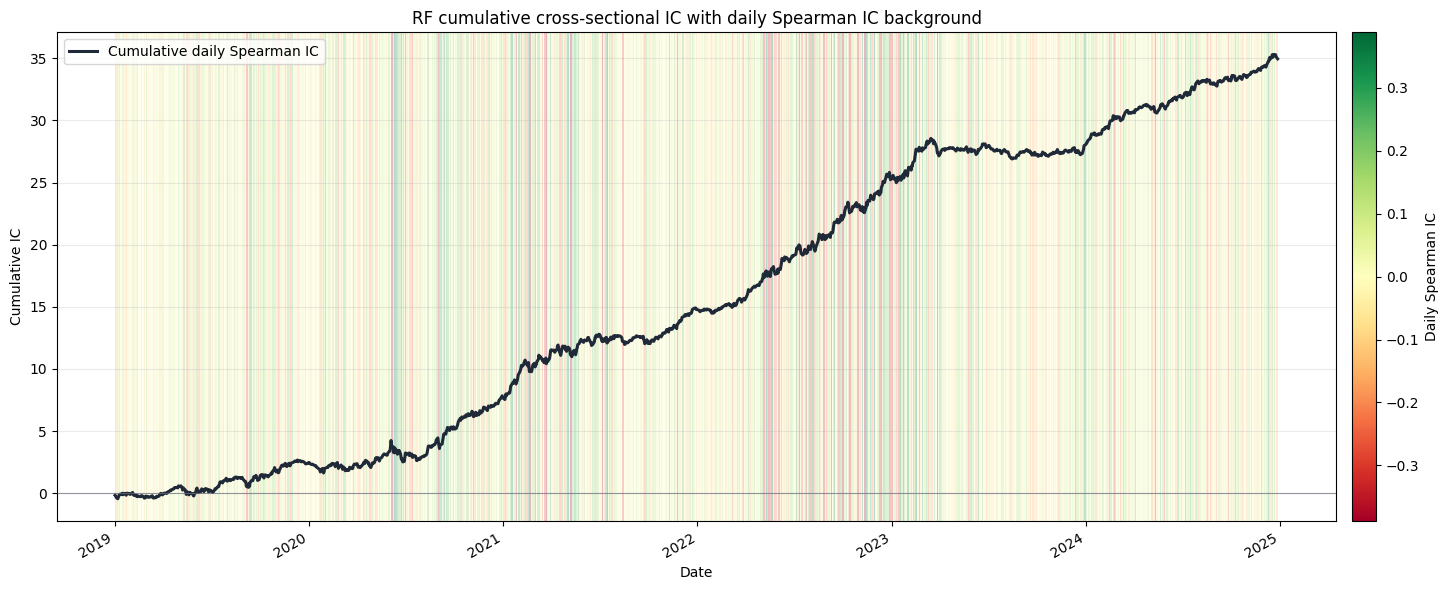

,year,ic_mean,ic_std,ic_tstat,n_days
0,2019,0.009707,0.104589,1.473405,252
1,2020,0.020681,0.151313,2.173965,253
2,2021,0.028208,0.169504,2.641781,252
3,2022,0.041592,0.190210,3.464275,251
4,2023,0.010944,0.140060,1.235526,250
5,2024,0.027963,0.116473,3.795975,250


,market_regime,ic_mean,ic_std,ic_tstat,n_days
0,down_market,0.033389,0.171048,4.294493,484
1,flat_market,0.025781,0.107534,4.655111,377
2,up_market,0.014024,0.150489,2.370363,647


,year,market_regime,ic_mean,ic_std,n_days,ic_tstat
0,2019,down_market,0.023154,0.118553,68,1.610538
1,2019,flat_market,0.026663,0.085293,79,2.778461
2,2019,up_market,-0.011758,0.105299,105,-1.144161
3,2020,down_market,-0.038454,0.155729,93,-2.381287
4,2020,flat_market,0.028631,0.125225,31,1.272991
5,2020,up_market,0.061402,0.140509,129,4.963375
6,2021,down_market,-0.152596,0.149026,57,-7.730709
7,2021,flat_market,0.001385,0.125131,78,0.097753
8,2021,up_market,0.134174,0.114810,117,12.641000
9,2022,down_market,0.164598,0.150913,105,11.176098


In [24]:
def summarize_ic_by_group(
    ic_df: pd.DataFrame,
    group_col: str,
    ic_col: str = "ic",
) -> pd.DataFrame:
    rows = []

    for group_value, g in ic_df.groupby(group_col):
        ic = pd.to_numeric(g[ic_col], errors="coerce").dropna()

        if ic.empty:
            rows.append({
                group_col: group_value,
                "ic_mean": np.nan,
                "ic_std": np.nan,
                "ic_tstat": np.nan,
                "n_days": 0,
            })
            continue

        ic_mean = ic.mean()
        ic_std = ic.std(ddof=1)
        n_days = len(ic)

        ic_tstat = np.nan
        if pd.notna(ic_std) and ic_std != 0:
            ic_tstat = ic_mean / ic_std * np.sqrt(n_days)

        rows.append({
            group_col: group_value,
            "ic_mean": ic_mean,
            "ic_std": ic_std,
            "ic_tstat": ic_tstat,
            "n_days": n_days,
        })

    return pd.DataFrame(rows).sort_values(group_col).reset_index(drop=True)


# -----------------------------
# 1. Daily cross-sectional IC
# -----------------------------
rf_ic_input = predictions_rf_cls.copy()
rf_ic_input["date"] = pd.to_datetime(rf_ic_input["date"])

rf_daily_ic = (
    daily_spearman_ic_fast(
        df=rf_ic_input,
        score_col="score",
        target_col="target_c2o_next_adj",
        date_col="date",
        min_names=30,
    )
    .rename("ic")
    .reset_index()
)

rf_daily_ic["date"] = pd.to_datetime(rf_daily_ic["date"])
rf_daily_ic["year"] = rf_daily_ic["date"].dt.year

overall_ic_summary = summarize_ic(rf_daily_ic["ic"])

rf_overall_ic_table = pd.DataFrame([{
    "model_name": "rf_classifier_top_bottom",
    "ic_mean": overall_ic_summary["ic_mean"],
    "ic_std": overall_ic_summary["ic_std"],
    "ic_tstat": overall_ic_summary["ic_tstat"],
    "n_days": overall_ic_summary["n_days"],
}])

display(rf_overall_ic_table)


# -----------------------------
# 2. Cumulative IC sequence with daily IC background
# -----------------------------
rf_daily_ic = rf_daily_ic.sort_values("date").reset_index(drop=True)
rf_daily_ic["cumulative_ic"] = rf_daily_ic["ic"].fillna(0.0).cumsum()

Path("prediction").mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(16, 6))
plot_dates = rf_daily_ic["date"]
plot_ic = rf_daily_ic["ic"].astype(float)
plot_cum_ic = rf_daily_ic["cumulative_ic"].astype(float)

max_abs_ic = plot_ic.abs().quantile(0.99)
if pd.isna(max_abs_ic) or max_abs_ic == 0:
    max_abs_ic = plot_ic.abs().max()
if pd.isna(max_abs_ic) or max_abs_ic == 0:
    max_abs_ic = 1.0

norm = plt.Normalize(vmin=-max_abs_ic, vmax=max_abs_ic)
cmap = plt.cm.RdYlGn

for i, row in rf_daily_ic.iterrows():
    start_date = row["date"]
    end_date = (
        rf_daily_ic.loc[i + 1, "date"]
        if i + 1 < len(rf_daily_ic)
        else start_date + pd.Timedelta(days=1)
    )
    ax.axvspan(
        start_date,
        end_date,
        color=cmap(norm(row["ic"])),
        alpha=0.28,
        linewidth=0,
    )

ax.plot(
    plot_dates,
    plot_cum_ic,
    color="#1f2937",
    linewidth=2.2,
    label="Cumulative daily Spearman IC",
)
ax.axhline(0, color="#6b7280", linewidth=0.8, alpha=0.7)
ax.set_title("RF cumulative cross-sectional IC with daily Spearman IC background")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative IC")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(loc="upper left")

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label("Daily Spearman IC")

fig.autofmt_xdate()
plt.tight_layout()
plt.savefig("prediction/rf_cumulative_ic_with_daily_ic_background.png", dpi=300, bbox_inches="tight")
plt.show()


# -----------------------------
# 3. IC stability across years
# -----------------------------
rf_yearly_ic_table = summarize_ic_by_group(
    ic_df=rf_daily_ic,
    group_col="year",
    ic_col="ic",
)

display(rf_yearly_ic_table)


# -----------------------------
# 4. Define simple market regimes
# -----------------------------
daily_market_return = (
    rf_ic_input
    .groupby("date")["target_c2o_next_adj"]
    .mean()
    .rename("equal_weight_market_return")
    .reset_index()
)

rf_daily_ic = rf_daily_ic.merge(
    daily_market_return,
    how="left",
    on="date",
    validate="1:1",
)

flat_threshold = rf_daily_ic["equal_weight_market_return"].abs().quantile(0.25)

rf_daily_ic["market_regime"] = np.select(
    [
        rf_daily_ic["equal_weight_market_return"] > flat_threshold,
        rf_daily_ic["equal_weight_market_return"] < -flat_threshold,
    ],
    [
        "up_market",
        "down_market",
    ],
    default="flat_market",
)

rf_regime_ic_table = summarize_ic_by_group(
    ic_df=rf_daily_ic,
    group_col="market_regime",
    ic_col="ic",
)

display(rf_regime_ic_table)


# -----------------------------
# 5. Optional combined year-regime stability table
# -----------------------------
rf_year_regime_ic_table = (
    rf_daily_ic
    .groupby(["year", "market_regime"])["ic"]
    .agg(
        ic_mean="mean",
        ic_std=lambda x: x.std(ddof=1),
        n_days="count",
    )
    .reset_index()
)

rf_year_regime_ic_table["ic_tstat"] = (
    rf_year_regime_ic_table["ic_mean"]
    / rf_year_regime_ic_table["ic_std"]
    * np.sqrt(rf_year_regime_ic_table["n_days"])
)

rf_year_regime_ic_table.loc[
    (rf_year_regime_ic_table["ic_std"].isna())
    | (rf_year_regime_ic_table["ic_std"].eq(0)),
    "ic_tstat"
] = np.nan

display(rf_year_regime_ic_table)




# 6. Save tables and chart inputs for report
Path("prediction").mkdir(parents=True, exist_ok=True)

rf_daily_ic.to_csv("prediction/rf_daily_ic.csv", index=False)
rf_overall_ic_table.to_csv("prediction/rf_overall_ic_table.csv", index=False)
rf_yearly_ic_table.to_csv("prediction/rf_yearly_ic_table.csv", index=False)
rf_regime_ic_table.to_csv("prediction/rf_regime_ic_table.csv", index=False)
rf_year_regime_ic_table.to_csv("prediction/rf_year_regime_ic_table.csv", index=False)


## 5-4 RF Feature Group Ablation

Train four leave-one-feature-group-out RF submodels. Each ablation uses the same walk-forward training logic as the full RF classifier: tune hyperparameters on the validation window, refit on the full train+validation window, and predict the next month. The only difference is that one feature group is removed from the candidate feature set.


In [ ]:
from pathlib import Path

rf_ablation_feature_groups = feature_groups.copy()
rf_ablation_feature_universe = list(dict.fromkeys(
    col
    for group_cols in rf_ablation_feature_groups.values()
    for col in group_cols
))


def build_ablation_valid_feature_cols_by_year(
    valid_feature_cols_by_year: dict[int, list[str]],
    feature_groups: dict[str, list[str]],
    removed_group: str,
) -> dict[int, list[str]]:
    """Build yearly valid feature columns after removing one feature group."""
    removed_cols = set(feature_groups[removed_group])
    allowed_cols = set(
        col
        for group_name, group_cols in feature_groups.items()
        if group_name != removed_group
        for col in group_cols
    )

    out = {}

    for year, valid_cols in valid_feature_cols_by_year.items():
        out[year] = [
            col for col in valid_cols
            if col in allowed_cols and col not in removed_cols
        ]

    return out


def summarize_prediction_sharpe_by_model(
    predictions: pd.DataFrame,
    model_col: str = "model_name",
    score_col: str = "score",
    target_col: str = "target_c2o_next_adj",
    date_col: str = "date",
    id_col: str = "instrument_id",
    trade_pct: float = 0.10,
    min_names: int = 30,
) -> pd.DataFrame:
    """Summarize no-cost long-short Sharpe for each prediction set."""
    if predictions.empty:
        return pd.DataFrame()

    rows = []

    for model_name, g in predictions.groupby(model_col):
        daily_ret, _ = build_no_cost_daily_return_from_scores(
            df=g,
            score_col=score_col,
            return_col=target_col,
            date_col=date_col,
            id_col=id_col,
            trade_pct=trade_pct,
            min_names=min_names,
        )

        row = {
            model_col: model_name,
            "n_prediction_rows": len(g),
            "n_prediction_days": pd.to_datetime(g[date_col]).nunique(),
        }
        row.update(summarize_daily_return(daily_ret, return_col="portfolio_return"))
        rows.append(row)

    return pd.DataFrame(rows)


all_ablation_predictions = []
all_ablation_diagnostics = []
ablation_feature_count_rows = []

for removed_group in rf_ablation_feature_groups:
    print('==========================================================================')
    print(f'                     Removed Group: {removed_group}')
    print('==========================================================================')

    ablation_valid_feature_cols_by_year = build_ablation_valid_feature_cols_by_year(
        valid_feature_cols_by_year=valid_feature_cols_by_year,
        feature_groups=rf_ablation_feature_groups,
        removed_group=removed_group,
    )

    for year in universe_years:
        ablation_feature_count_rows.append({
            "removed_feature_group": removed_group,
            "universe_year": year,
            "n_features_used": len(ablation_valid_feature_cols_by_year.get(year, [])),
        })

    pred, diag = run_classifier_daily_walk_forward_all_universes(
        all_dfs_z=all_dfs_z,
        universe_years=universe_years,
        valid_feature_cols_by_year=ablation_valid_feature_cols_by_year,
        model_factory=make_rf_classifier,
        param_grid=rf_classifier_param_grid,
        model_name=f"rf_without_{removed_group}",
        label_pct=0.10,
        trade_pct=0.49999,
        selection_metric="return",
        target_col_raw="target_c2o_next_adj",
        date_col="date",
        id_col="instrument_id",
        eligibility_col="is_eligible",
        whole_train_days=whole_train_days,
        val_days=val_days,
        predict_days=predict_days,
        use_permutation_feature_filter=True,
        permutation_filter_model_factory=make_rf_classifier,
        permutation_filter_params=rf_permutation_filter_params,
        permutation_filter_scoring="balanced_accuracy",
        permutation_filter_n_repeats=10,
        permutation_filter_random_state=2026,
        permutation_filter_min_features=5,
        permutation_cluster_corr_threshold=rf_permutation_cluster_corr_threshold,
        use_cluster_pca_features=True,
    )

    if not pred.empty:
        pred["removed_feature_group"] = removed_group
        all_ablation_predictions.append(pred)

    if not diag.empty:
        diag["removed_feature_group"] = removed_group
        all_ablation_diagnostics.append(diag)

predictions_rf_group_ablation = (
    pd.concat(all_ablation_predictions, ignore_index=True)
    if all_ablation_predictions
    else pd.DataFrame()
)

diagnostics_rf_group_ablation = (
    pd.concat(all_ablation_diagnostics, ignore_index=True)
    if all_ablation_diagnostics
    else pd.DataFrame()
)

rf_group_ablation_feature_counts = pd.DataFrame(ablation_feature_count_rows)

summary_rf_group_ablation = summarize_prediction_sharpe_by_model(
    predictions=predictions_rf_group_ablation,
    model_col="model_name",
    score_col="score",
    target_col="target_c2o_next_adj",
    date_col="date",
    id_col="instrument_id",
    trade_pct=0.49999,
    min_names=30,
)

if not summary_rf_group_ablation.empty:
    summary_rf_group_ablation["removed_feature_group"] = (
        summary_rf_group_ablation["model_name"]
        .str.replace("rf_without_", "", regex=False)
    )

    if "predictions_rf_cls" in globals() and not predictions_rf_cls.empty:
        full_rf_summary = summarize_prediction_sharpe_by_model(
            predictions=predictions_rf_cls.assign(model_name="rf_full"),
            model_col="model_name",
            score_col="score",
            target_col="target_c2o_next_adj",
            date_col="date",
            id_col="instrument_id",
            trade_pct=0.49999,
            min_names=30,
        )

        if not full_rf_summary.empty:
            full_rf_sharpe = full_rf_summary.loc[0, "sharpe"]
            full_rf_ann_return = full_rf_summary.loc[0, "annualized_return"]
            summary_rf_group_ablation["full_rf_sharpe"] = full_rf_sharpe
            summary_rf_group_ablation["full_rf_annualized_return"] = full_rf_ann_return
            summary_rf_group_ablation["sharpe_delta_vs_full_rf"] = (
                summary_rf_group_ablation["sharpe"] - full_rf_sharpe
            )
            summary_rf_group_ablation["annualized_return_delta_vs_full_rf"] = (
                summary_rf_group_ablation["annualized_return"] - full_rf_ann_return
            )

    summary_rf_group_ablation = (
        summary_rf_group_ablation
        .sort_values("sharpe", ascending=False)
        .reset_index(drop=True)
    )

Path("prediction").mkdir(parents=True, exist_ok=True)
predictions_rf_group_ablation.to_csv("prediction/predictions_rf_group_ablation.csv", index=False)
diagnostics_rf_group_ablation.to_csv("prediction/diagnostics_rf_group_ablation.csv", index=False)
summary_rf_group_ablation.to_csv("prediction/summary_rf_group_ablation.csv", index=False)
rf_group_ablation_feature_counts.to_csv("prediction/rf_group_ablation_feature_counts.csv", index=False)




                     Removed Group: fundamental


KeyboardInterrupt: 

In [75]:
print("RF leave-one-feature-group-out ablation summary:")
display(summary_rf_group_ablation)

print("Number of features used by ablation model and universe year:")
display(rf_group_ablation_feature_counts.head(20))

RF leave-one-feature-group-out ablation summary:


,model_name,n_prediction_rows,n_prediction_days,mean_daily_return,total_return_simple,annualized_return,annualized_volatility,sharpe,n_return_days,removed_feature_group,full_rf_sharpe,full_rf_annualized_return,sharpe_delta_vs_full_rf,annualized_return_delta_vs_full_rf
0,rf_without_technical_indicator,1507979,1508,0.000117,0.176255,0.029454,0.018690,1.575946,1508,technical_indicator,1.351041,0.025887,0.224905,0.003567
1,rf_without_short_interest,1507979,1508,0.000107,0.161234,0.026944,0.018981,1.419488,1508,short_interest,1.351041,0.025887,0.068448,0.001056
2,rf_without_fundamental,1507979,1508,0.000106,0.160553,0.026830,0.019364,1.385579,1508,fundamental,1.351041,0.025887,0.034538,0.000943
3,rf_without_earnings,1507979,1508,0.000098,0.147662,0.024676,0.018848,1.309208,1508,earnings,1.351041,0.025887,-0.041833,-0.001212
4,rf_without_returns_volatility_liquidity,1507979,1508,0.000084,0.126170,0.021084,0.017477,1.206386,1508,returns_volatility_liquidity,1.351041,0.025887,-0.144655,-0.004803


Number of features used by ablation model and universe year:


,removed_feature_group,universe_year,n_features_used
0,fundamental,2019,140
1,fundamental,2020,140
2,fundamental,2021,140
3,fundamental,2022,140
4,fundamental,2023,140
5,fundamental,2024,140
6,earnings,2019,250
7,earnings,2020,250
8,earnings,2021,250
9,earnings,2022,250


## 5-5 RF Ablation Cumulative IC

Compute daily cross-sectional IC for the full RF model and each leave-one-feature-group-out RF model, then plot all cumulative IC series in one comparison figure.


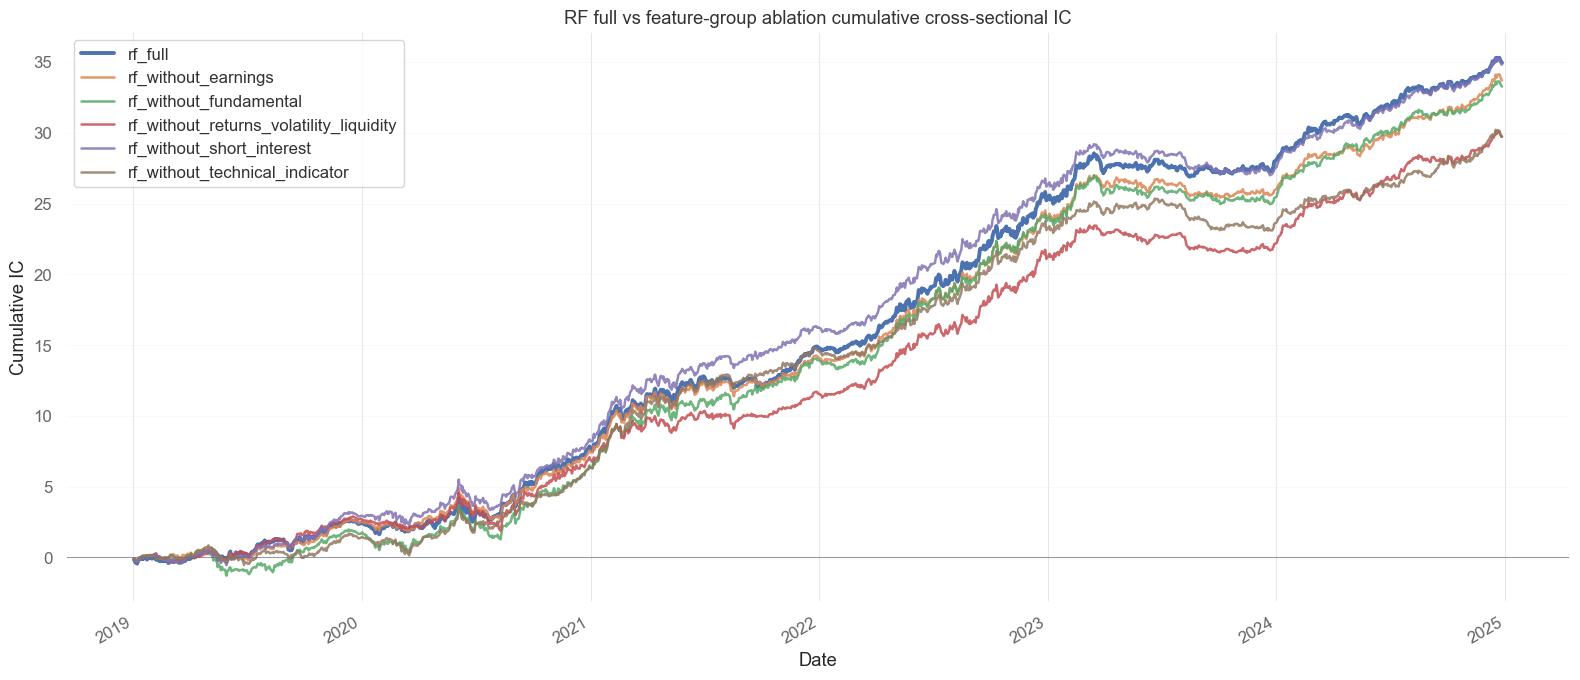

RF full and feature-group ablation IC summary:


,model_name,ic_mean,ic_std,ic_tstat,n_days
0,rf_full,0.023179,0.148463,6.062745,1508
1,rf_without_earnings,0.022351,0.147015,5.903979,1508
2,rf_without_fundamental,0.022063,0.150779,5.682320,1508
3,rf_without_returns_volatility_liquidity,0.019707,0.136361,5.612323,1508
4,rf_without_short_interest,0.023094,0.146662,6.114841,1508
5,rf_without_technical_indicator,0.019723,0.141379,5.417372,1508


In [76]:
import matplotlib.pyplot as plt
from pathlib import Path


def compute_daily_ic_for_predictions(
    predictions: pd.DataFrame,
    model_name: str,
    score_col: str = "score",
    target_col: str = "target_c2o_next_adj",
    date_col: str = "date",
    min_names: int = 30,
) -> pd.DataFrame:
    temp = predictions.copy()
    temp[date_col] = pd.to_datetime(temp[date_col])

    daily_ic = (
        daily_spearman_ic_fast(
            df=temp,
            score_col=score_col,
            target_col=target_col,
            date_col=date_col,
            min_names=min_names,
        )
        .rename("ic")
        .reset_index()
    )

    daily_ic[date_col] = pd.to_datetime(daily_ic[date_col])
    daily_ic = daily_ic.sort_values(date_col).reset_index(drop=True)
    daily_ic["model_name"] = model_name
    daily_ic["cumulative_ic"] = daily_ic["ic"].fillna(0.0).cumsum()
    return daily_ic


Path("prediction").mkdir(parents=True, exist_ok=True)
Path("figures").mkdir(parents=True, exist_ok=True)

ic_prediction_sets = []

if "predictions_rf_cls" in globals() and not predictions_rf_cls.empty:
    ic_prediction_sets.append(("rf_full", predictions_rf_cls.copy()))

if "predictions_rf_group_ablation" in globals() and not predictions_rf_group_ablation.empty:
    for model_name, model_pred in predictions_rf_group_ablation.groupby("model_name"):
        ic_prediction_sets.append((model_name, model_pred.copy()))

rf_ablation_ic_summary_rows = []
rf_ablation_daily_ic_list = []

for model_name, model_pred in ic_prediction_sets:
    model_daily_ic = compute_daily_ic_for_predictions(
        predictions=model_pred,
        model_name=model_name,
        score_col="score",
        target_col="target_c2o_next_adj",
        date_col="date",
        min_names=30,
    )

    if model_daily_ic.empty:
        continue

    ic_summary = summarize_ic(model_daily_ic["ic"])
    rf_ablation_ic_summary_rows.append({
        "model_name": model_name,
        "ic_mean": ic_summary["ic_mean"],
        "ic_std": ic_summary["ic_std"],
        "ic_tstat": ic_summary["ic_tstat"],
        "n_days": ic_summary["n_days"],
    })
    rf_ablation_daily_ic_list.append(model_daily_ic)

rf_ablation_ic_summary = pd.DataFrame(rf_ablation_ic_summary_rows)

if not rf_ablation_ic_summary.empty:
    rf_ablation_ic_summary = rf_ablation_ic_summary.sort_values(
        ["model_name"]
    ).reset_index(drop=True)

rf_ablation_daily_ic = (
    pd.concat(rf_ablation_daily_ic_list, ignore_index=True)
    if rf_ablation_daily_ic_list
    else pd.DataFrame()
)

if not rf_ablation_daily_ic.empty:
    fig, ax = plt.subplots(figsize=(16, 7))

    plot_order = ["rf_full"] + sorted(
        [m for m in rf_ablation_daily_ic["model_name"].unique() if m != "rf_full"]
    )

    for model_name in plot_order:
        model_ic = rf_ablation_daily_ic.loc[
            rf_ablation_daily_ic["model_name"].eq(model_name)
        ].sort_values("date")

        if model_ic.empty:
            continue

        linewidth = 2.8 if model_name == "rf_full" else 1.8
        alpha = 1.0 if model_name == "rf_full" else 0.85
        ax.plot(
            model_ic["date"],
            model_ic["cumulative_ic"],
            linewidth=linewidth,
            alpha=alpha,
            label=model_name,
        )

    ax.axhline(0, color="#6b7280", linewidth=0.8, alpha=0.7)
    ax.set_title("RF full vs feature-group ablation cumulative cross-sectional IC")
    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative IC")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(loc="best")
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.savefig("figures/rf_full_and_ablation_cumulative_ic_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()

rf_ablation_ic_summary.to_csv("prediction/rf_ablation_ic_summary.csv", index=False)
rf_ablation_daily_ic.to_csv("prediction/rf_ablation_daily_ic.csv", index=False)

print("RF full and feature-group ablation IC summary:")
display(rf_ablation_ic_summary)


### 5-5 Identify at least two regimes or sub-periods where the IC is weak.
The model performs badly when the IC becomes weak or negative. The first weak area is the worst yearly IC period, shown in the yearly IC table. During this year, the model's ranking signal failed to line up with realized close-to-open returns. This likely happened because the six-month training window learned relationships that did not persist into the prediction month.

The second weak area is the weakest market regime, shown in the regime IC table. In this regime, returns are probably driven more by broad market moves, overnight news, and liquidity shocks than by stock-specific features. This makes cross-sectional ranking harder, especially for a model using mostly price-volume, fundamental, earnings, and short-interest features.

The rolling six-month IC table also shows that the model has unstable sub-periods. Therefore, the RF model should not be treated as uniformly predictive. A practical improvement would be to monitor rolling IC and reduce trading exposure when recent IC is weak.

# Section 6 
# Results

In [26]:
def build_threshold_dollar_neutral_daily_returns(
    signal_df: pd.DataFrame,
    aum: float,
    position_divisor: float = 400.0,
    score_center_method: str = "mean",
    score_std_multiplier: float = 1.0,
    max_names_per_side: int = 200,
    date_col: str = "date",
    id_col: str = "instrument_id",
    score_col: str = "score",
    return_col: str = "target_c2o_next_adj",
    eligible_col: str = "is_eligible",
    commission_bps_col: str = "commission_bps",
    slippage_bps_col: str = "slippage_bps",
    borrow_rate_daily_col: str = "borrow_rate_daily",
    default_commission_bps: float = 1.0,
    default_slippage_bps: float = 0.0,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Build a threshold-based dollar-neutral long-short portfolio.

    Rules:
    - Center can be daily cross-sectional mean, median, or zero.
    - Long candidates: eligible names with score >= center + score_std_multiplier * daily std.
    - Short candidates: eligible names with score <= center - score_std_multiplier * daily std.
    - Use the smaller side count each day, capped by max_names_per_side, to keep long and short baskets equal-sized.
    - Each selected stock receives fixed dollar notional: AUM / position_divisor.
    - Portfolio return is dollar PnL divided by total AUM.
    - Commission and slippage are charged on traded dollars; borrow is charged on short notional.
    """

    df = signal_df.copy()
    df[date_col] = pd.to_datetime(df[date_col])

    required_cols = [
        date_col,
        id_col,
        score_col,
        return_col,
        eligible_col,
        commission_bps_col,
        slippage_bps_col,
        borrow_rate_daily_col,
    ]

    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns: {missing_cols}")

    for col in [score_col, return_col, commission_bps_col, slippage_bps_col, borrow_rate_daily_col]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.loc[df[eligible_col].eq(True)].copy()
    df = df.dropna(subset=required_cols).copy()

    position_per_stock = float(aum) / float(position_divisor)
    position_rows = []
    basket_rows = []

    valid_center_methods = {"mean", "median", "zero"}
    if score_center_method not in valid_center_methods:
        raise ValueError(f"score_center_method must be one of {valid_center_methods}.")

    for trade_date, day_df in df.groupby(date_col, sort=True):
        daily_score_mean = day_df[score_col].mean()
        daily_score_median = day_df[score_col].median()
        daily_score_std = day_df[score_col].std(ddof=0)

        if pd.isna(daily_score_std):
            daily_score_std = 0.0

        if score_center_method == "mean":
            score_center = daily_score_mean
        elif score_center_method == "median":
            score_center = daily_score_median
        else:
            score_center = 0.0

        long_threshold = score_center + score_std_multiplier * daily_score_std
        short_threshold = score_center - score_std_multiplier * daily_score_std

        long_candidates = (
            day_df.loc[day_df[score_col] >= long_threshold]
            .sort_values(score_col, ascending=False)
            .copy()
        )
        short_candidates = (
            day_df.loc[day_df[score_col] <= short_threshold]
            .sort_values(score_col, ascending=True)
            .copy()
        )

        n_long_candidates = len(long_candidates)
        n_short_candidates = len(short_candidates)
        n_side = min(n_long_candidates, n_short_candidates, int(max_names_per_side))

        basket_rows.append({
            date_col: trade_date,
            "score_center_method": score_center_method,
            "score_std_multiplier": score_std_multiplier,
            "daily_score_mean": daily_score_mean,
            "daily_score_median": daily_score_median,
            "daily_score_std": daily_score_std,
            "score_center": score_center,
            "long_score_threshold": long_threshold,
            "short_score_threshold": short_threshold,
            "max_names_per_side": max_names_per_side,
            "n_long_candidates": n_long_candidates,
            "n_short_candidates": n_short_candidates,
            "n_side_selected": n_side,
            "position_per_stock": position_per_stock,
            "long_notional": n_side * position_per_stock,
            "short_notional": n_side * position_per_stock,
            "gross_notional": 2.0 * n_side * position_per_stock,
            "net_notional": 0.0,
        })

        if n_side == 0:
            continue

        longs = long_candidates.head(n_side).copy()
        longs["side"] = 1
        shorts = short_candidates.head(n_side).copy()
        shorts["side"] = -1

        selected = pd.concat([longs, shorts], axis=0, ignore_index=True)
        selected["position_per_stock"] = position_per_stock
        selected["position_dollar"] = position_per_stock
        selected["signed_position_dollar"] = selected["side"] * position_per_stock
        position_rows.append(selected)

    basket_summary = pd.DataFrame(basket_rows)

    if not position_rows:
        empty_daily = basket_summary.copy()
        for col in [
            "gross_pnl", "commission_cost_dollar", "slippage_cost_dollar", "borrow_cost_dollar",
            "pnl_after_commission", "pnl_after_slippage", "net_pnl", "traded_dollar",
            "turnover", "portfolio_return_gross", "portfolio_return_after_commission",
            "portfolio_return_after_slippage", "portfolio_return_net",
        ]:
            empty_daily[col] = 0.0
        return empty_daily, pd.DataFrame(), basket_summary

    position_df = (
        pd.concat(position_rows, axis=0, ignore_index=True)
        .sort_values([date_col, id_col])
        .reset_index(drop=True)
    )

    position_df["gross_pnl"] = position_df["signed_position_dollar"] * position_df[return_col]
    position_df["borrow_cost_dollar"] = np.where(
        position_df["side"].eq(-1),
        position_df["position_dollar"] * position_df[borrow_rate_daily_col],
        0.0,
    )

    position_df["long_pnl"] = np.where(position_df["side"].eq(1), position_df["gross_pnl"], 0.0)
    position_df["short_pnl"] = np.where(position_df["side"].eq(-1), position_df["gross_pnl"], 0.0)

    # The signal is a close-to-next-open holding period, so every selected name is traded each day.
    # Do not net positions against yesterday; same-name consecutive holdings still require a new daily trade.
    trade_df = position_df[[
        date_col,
        id_col,
        "position_dollar",
        commission_bps_col,
        slippage_bps_col,
    ]].copy()
    trade_df["abs_trade_dollar"] = trade_df["position_dollar"].abs()
    trade_df[commission_bps_col] = trade_df[commission_bps_col].fillna(default_commission_bps)
    trade_df[slippage_bps_col] = trade_df[slippage_bps_col].fillna(default_slippage_bps)
    trade_df["commission_cost_dollar"] = trade_df["abs_trade_dollar"] * trade_df[commission_bps_col] / 10000.0
    trade_df["slippage_cost_dollar"] = trade_df["abs_trade_dollar"] * trade_df[slippage_bps_col] / 10000.0

    daily_pnl = (
        position_df
        .groupby(date_col)
        .agg(
            gross_pnl=("gross_pnl", "sum"),
            long_pnl=("long_pnl", "sum"),
            short_pnl=("short_pnl", "sum"),
            borrow_cost_dollar=("borrow_cost_dollar", "sum"),
            n_long_actual=("side", lambda x: int((x == 1).sum())),
            n_short_actual=("side", lambda x: int((x == -1).sum())),
            long_notional=("position_dollar", lambda x: float(x[position_df.loc[x.index, "side"].eq(1)].sum())),
            short_notional=("position_dollar", lambda x: float(x[position_df.loc[x.index, "side"].eq(-1)].sum())),
        )
        .reset_index()
    )

    daily_trades = (
        trade_df
        .groupby(date_col)
        .agg(
            traded_dollar=("abs_trade_dollar", "sum"),
            commission_cost_dollar=("commission_cost_dollar", "sum"),
            slippage_cost_dollar=("slippage_cost_dollar", "sum"),
        )
        .reset_index()
    )

    daily_return_df = basket_summary.merge(daily_pnl, how="left", on=date_col)
    daily_return_df = daily_return_df.merge(daily_trades, how="left", on=date_col)

    fill_zero_cols = [
        "gross_pnl", "long_pnl", "short_pnl", "borrow_cost_dollar", "n_long_actual", "n_short_actual",
        "long_notional_y", "short_notional_y", "traded_dollar", "commission_cost_dollar", "slippage_cost_dollar",
    ]
    for col in fill_zero_cols:
        if col in daily_return_df.columns:
            daily_return_df[col] = daily_return_df[col].fillna(0.0)

    if "long_notional_y" in daily_return_df.columns:
        daily_return_df["long_notional"] = daily_return_df["long_notional_y"].fillna(daily_return_df["long_notional_x"])
        daily_return_df["short_notional"] = daily_return_df["short_notional_y"].fillna(daily_return_df["short_notional_x"])
        daily_return_df = daily_return_df.drop(columns=[c for c in ["long_notional_x", "short_notional_x", "long_notional_y", "short_notional_y"] if c in daily_return_df.columns])

    daily_return_df["pnl_after_commission"] = daily_return_df["gross_pnl"] - daily_return_df["commission_cost_dollar"]
    daily_return_df["pnl_after_slippage"] = daily_return_df["pnl_after_commission"] - daily_return_df["slippage_cost_dollar"]
    daily_return_df["net_pnl"] = daily_return_df["pnl_after_slippage"] - daily_return_df["borrow_cost_dollar"]

    daily_return_df["turnover"] = daily_return_df["traded_dollar"] / float(aum)
    daily_return_df["portfolio_return_gross"] = daily_return_df["gross_pnl"] / float(aum)
    daily_return_df["portfolio_return_after_commission"] = daily_return_df["pnl_after_commission"] / float(aum)
    daily_return_df["portfolio_return_after_slippage"] = daily_return_df["pnl_after_slippage"] / float(aum)
    daily_return_df["portfolio_return_net"] = daily_return_df["net_pnl"] / float(aum)

    daily_return_df["portfolio_commission_cost"] = daily_return_df["commission_cost_dollar"] / float(aum)
    daily_return_df["portfolio_slippage_cost"] = daily_return_df["slippage_cost_dollar"] / float(aum)
    daily_return_df["portfolio_borrow_cost"] = daily_return_df["borrow_cost_dollar"] / float(aum)
    daily_return_df["portfolio_trading_cost"] = (
        daily_return_df["portfolio_commission_cost"]
        + daily_return_df["portfolio_slippage_cost"]
    )

    for stage in ["gross", "after_commission", "after_slippage", "net"]:
        daily_return_df[f"cum_return_{stage}"] = (
            daily_return_df[f"portfolio_return_{stage}"].fillna(0.0)
        ).cumsum()

    return daily_return_df, position_df, basket_summary


In [27]:
def compute_performance_metrics(
    daily_return_df: pd.DataFrame,
    return_col: str = "portfolio_return_net",
    date_col: str = "date",
    periods_per_year: int = 252,
    use_simple_pnl: bool = True,
) -> pd.Series:
    df = daily_return_df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col)

    r = pd.to_numeric(df[return_col], errors="coerce").dropna()

    if r.empty:
        return pd.Series(dtype=float)

    n_days = len(r)

    if use_simple_pnl:
        equity = 1.0 + r.cumsum()
        total_return = r.sum()
        ann_return = r.mean() * periods_per_year
    else:
        equity = (1.0 + r).cumprod()
        total_return = equity.iloc[-1] - 1.0
        ann_return = equity.iloc[-1] ** (periods_per_year / n_days) - 1.0

    ann_vol = r.std(ddof=1) * np.sqrt(periods_per_year)

    sharpe = np.nan
    if pd.notna(ann_vol) and ann_vol != 0:
        sharpe = ann_return / ann_vol

    running_max = equity.cummax()
    drawdown = equity / running_max - 1.0
    max_drawdown = drawdown.min()

    calmar = np.nan
    if pd.notna(max_drawdown) and max_drawdown != 0:
        calmar = ann_return / abs(max_drawdown)

    win_rate = (r > 0).mean()

    return pd.Series({
        "n_days": n_days,
        "total_return": total_return,
        "annualized_return": ann_return,
        "annualized_volatility": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown,
        "calmar": calmar,
        "win_rate": win_rate,
        "avg_daily_return": r.mean(),
        "daily_volatility": r.std(ddof=1),
        "best_day": r.max(),
        "worst_day": r.min(),
        "pnl_convention": "simple_cumulative" if use_simple_pnl else "compounded",
    })

In [49]:
def plot_pnl(
    daily_return_df: pd.DataFrame,
    date_col: str = "date",
    save_path = None,
):
    df = daily_return_df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col)

    fig, ax = plt.subplots(figsize=(10, 8))

    ax.plot(
        df[date_col],
        df["cum_return_gross"],
        linewidth=2.0,
        label="Gross return",
    )

    ax.plot(
        df[date_col],
        df["cum_return_net"],
        linewidth=2.0,
        label="Net return",
    )

    ax.set_title("Long-Short Strategy Return", fontsize=16, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Return")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

In [29]:
def run_backtest_for_one_aum(
    predictions: pd.DataFrame,
    eligibility_df: pd.DataFrame,
    df_hardtoborrow: pd.DataFrame,
    aum_label: str,
    aum: float,
    position_divisor: float = 400.0,
    score_center_method: str = "mean",
    score_std_multiplier: float = 1.0,
    max_names_per_side: int = 200,
    figure_dir: str = "figures",
    commission_bps: float = 1.0,
    total_trading_cost_bps_override = 4.0,
    start_date: str = "2010-01-01",
    end_date: str = "2024-12-31",
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Run the Section 6.3 AUM-aware backtest.

    The strategy uses configurable center +/- n daily score standard deviations instead of fixed basket sizes. Each selected
    stock receives AUM / position_divisor notional, and the smaller of the long and
    short candidate counts is used each day, capped by max_names_per_side, to keep the portfolio dollar-neutral.
    """

    from pathlib import Path

    Path(figure_dir).mkdir(parents=True, exist_ok=True)

    predict_cols = [
        "instrument_id",
        "date",
        "target_c2o_next_adj",
        "score",
    ]

    eligibility_cols = [
        "instrument_id",
        "date",
        "slippage_commission_bps",
        "is_eligible",
    ]

    borrow_cols = [
        "instrument_id",
        "date",
        "borrow_rate_daily",
    ]

    pred = predictions[predict_cols].copy()
    elig = eligibility_df[eligibility_cols].copy()
    borrow = df_hardtoborrow[borrow_cols].copy()

    pred["date"] = pd.to_datetime(pred["date"])
    elig["date"] = pd.to_datetime(elig["date"])
    borrow["date"] = pd.to_datetime(borrow["date"])

    start_ts = pd.Timestamp(start_date)
    end_ts = pd.Timestamp(end_date)
    pred = pred.loc[pred["date"].between(start_ts, end_ts)].copy()
    elig = elig.loc[elig["date"].between(start_ts, end_ts)].copy()
    borrow = borrow.loc[borrow["date"].between(start_ts, end_ts)].copy()

    pred["instrument_id"] = pred["instrument_id"].astype(int)
    elig["instrument_id"] = elig["instrument_id"].astype(int)
    borrow["instrument_id"] = borrow["instrument_id"].astype(int)

    signal_df = pred.merge(
        elig,
        how="left",
        on=["instrument_id", "date"],
        validate="m:1",
    )

    signal_df = signal_df.merge(
        borrow,
        how="left",
        on=["instrument_id", "date"],
        validate="m:1",
    )

    signal_df["borrow_rate_daily"] = signal_df["borrow_rate_daily"].fillna(0.004 / 252)
    signal_df["is_eligible"] = signal_df["is_eligible"].fillna(False).astype(bool)

    if total_trading_cost_bps_override is None:
        signal_df["total_trading_cost_bps"] = pd.to_numeric(
            signal_df["slippage_commission_bps"],
            errors="coerce",
        )
    else:
        signal_df["total_trading_cost_bps"] = float(total_trading_cost_bps_override)

    signal_df["commission_bps"] = float(commission_bps)
    signal_df["slippage_bps"] = (
        signal_df["total_trading_cost_bps"]
        - signal_df["commission_bps"]
    ).clip(lower=0.0)

    daily_ret, position_df, basket_summary = build_threshold_dollar_neutral_daily_returns(
        signal_df=signal_df,
        aum=aum,
        position_divisor=position_divisor,
        score_center_method=score_center_method,
        score_std_multiplier=score_std_multiplier,
        max_names_per_side=max_names_per_side,
        date_col="date",
        id_col="instrument_id",
        score_col="score",
        return_col="target_c2o_next_adj",
        eligible_col="is_eligible",
        commission_bps_col="commission_bps",
        slippage_bps_col="slippage_bps",
        borrow_rate_daily_col="borrow_rate_daily",
        default_commission_bps=commission_bps,
        default_slippage_bps=max(float(total_trading_cost_bps_override or commission_bps) - float(commission_bps), 0.0),
    )

    metric_map = {
        "gross": "portfolio_return_gross",
        "after_commission": "portfolio_return_after_commission",
        "after_slippage": "portfolio_return_after_slippage",
        "net": "portfolio_return_net",
    }

    performance_table = pd.concat(
        [
            compute_performance_metrics(
                daily_return_df=daily_ret,
                return_col=return_col,
                date_col="date",
                periods_per_year=252,
            ).rename(stage)
            for stage, return_col in metric_map.items()
        ],
        axis=1,
    )

    performance_table["aum_label"] = aum_label
    performance_table["aum"] = aum
    performance_table["position_per_stock"] = aum / position_divisor
    performance_table["position_divisor"] = position_divisor
    performance_table["score_center_method"] = score_center_method
    performance_table["score_std_multiplier"] = score_std_multiplier
    performance_table["max_names_per_side"] = max_names_per_side
    performance_table["commission_bps"] = commission_bps
    performance_table["total_trading_cost_bps_override"] = total_trading_cost_bps_override
    performance_table["start_date"] = start_date
    performance_table["end_date"] = end_date

    sharpe_by_stage = performance_table.loc["sharpe"]
    degradation_table = pd.DataFrame([{
        "aum_label": aum_label,
        "aum": aum,
        "gross_sharpe": sharpe_by_stage["gross"],
        "after_commission_sharpe": sharpe_by_stage["after_commission"],
        "after_slippage_sharpe": sharpe_by_stage["after_slippage"],
        "net_sharpe": sharpe_by_stage["net"],
        "commission_sharpe_points": sharpe_by_stage["gross"] - sharpe_by_stage["after_commission"],
        "slippage_sharpe_points": sharpe_by_stage["after_commission"] - sharpe_by_stage["after_slippage"],
        "borrow_sharpe_points": sharpe_by_stage["after_slippage"] - sharpe_by_stage["net"],
        "total_gross_to_net_sharpe_points": sharpe_by_stage["gross"] - sharpe_by_stage["net"],
        "avg_daily_commission_cost_return": daily_ret["portfolio_commission_cost"].mean(),
        "avg_daily_slippage_cost_return": daily_ret["portfolio_slippage_cost"].mean(),
        "avg_daily_borrow_cost_return": daily_ret["portfolio_borrow_cost"].mean(),
        "avg_daily_trading_cost_return": daily_ret["portfolio_trading_cost"].mean(),
        "avg_daily_commission_cost_dollar": daily_ret["commission_cost_dollar"].mean(),
        "avg_daily_slippage_cost_dollar": daily_ret["slippage_cost_dollar"].mean(),
        "avg_daily_borrow_cost_dollar": daily_ret["borrow_cost_dollar"].mean(),
        "commission_bps": commission_bps,
        "avg_slippage_bps": signal_df.loc[signal_df["is_eligible"], "slippage_bps"].mean(),
        "avg_total_trading_cost_bps": signal_df.loc[signal_df["is_eligible"], "total_trading_cost_bps"].mean(),
    }])

    basket_stats = pd.DataFrame([{
        "aum_label": aum_label,
        "aum": aum,
        "position_per_stock": aum / position_divisor,
        "position_divisor": position_divisor,
        "score_center_method": score_center_method,
        "score_std_multiplier": score_std_multiplier,
        "max_names_per_side": max_names_per_side,
        "avg_score_center": daily_ret["score_center"].mean(),
        "avg_long_score_threshold": daily_ret["long_score_threshold"].mean(),
        "avg_short_score_threshold": daily_ret["short_score_threshold"].mean(),
        "avg_daily_score_mean": daily_ret["daily_score_mean"].mean(),
        "avg_daily_score_median": daily_ret["daily_score_median"].mean(),
        "avg_daily_score_std": daily_ret["daily_score_std"].mean(),
        "avg_long_basket_size": daily_ret["n_long_actual"].mean(),
        "avg_short_basket_size": daily_ret["n_short_actual"].mean(),
        "median_long_basket_size": daily_ret["n_long_actual"].median(),
        "median_short_basket_size": daily_ret["n_short_actual"].median(),
        "avg_long_candidates": daily_ret["n_long_candidates"].mean(),
        "avg_short_candidates": daily_ret["n_short_candidates"].mean(),
        "avg_gross_exposure": daily_ret["gross_notional"].mean() / aum,
        "avg_long_exposure": daily_ret["long_notional"].mean() / aum,
        "avg_short_exposure": daily_ret["short_notional"].mean() / aum,
        "avg_daily_turnover": daily_ret["turnover"].mean(),
        "median_daily_turnover": daily_ret["turnover"].median(),
        "avg_daily_traded_dollar": daily_ret["traded_dollar"].mean(),
        "n_trading_days": len(daily_ret),
    }])

    plot_pnl(
        daily_return_df=daily_ret,
        date_col="date",
        save_path=f"{figure_dir}/rf_cls_{aum_label}_pnl.png",
    )

    return signal_df, daily_ret, performance_table, degradation_table, basket_stats


## 6-2 + 6-3
## AUM-aware basket construction, headline performance, and Sharpe degradation

This section uses the Section 6.3 cost schedule on 2010-2024 only. Positions are selected using configurable daily score thresholds:

- choose the daily cross-sectional center as `mean`, `median`, or fixed `zero`
- long candidates: eligible stocks with `score >= center + n * daily std(score)`
- short candidates: eligible stocks with `score <= center - n * daily std(score)`
- the daily basket size is the smaller of the long and short candidate counts, capped at 200 names per side, so the book is dollar-neutral
- each selected stock receives fixed notional equal to `AUM / 400`
- daily return is true dollar PnL divided by total AUM
- daily turnover is daily selected gross traded dollars divided by AUM, so repeated names are still counted as traded each day

Gross-to-net Sharpe degradation is decomposed sequentially as:

- commission points = Sharpe(gross) - Sharpe(after commission)
- slippage points = Sharpe(after commission) - Sharpe(after slippage)
- borrow points = Sharpe(after slippage) - Sharpe(net)

Commission and slippage are charged on daily traded dollars. Borrow is charged daily on short notional.


In [5]:
import pandas as pd 
predictions_rf_cls = pd.read_csv('prediction/predictions_rf_cls.csv')

df_hardtoborrow = pd.read_parquet("data/df_hardtoborrow.parquet")
eligibility_50m = pd.read_parquet("data/eligibility_50m.parquet")
eligibility_250m = pd.read_parquet("data/eligibility_250m.parquet")
eligibility_1b = pd.read_parquet("data/eligibility_1b.parquet")

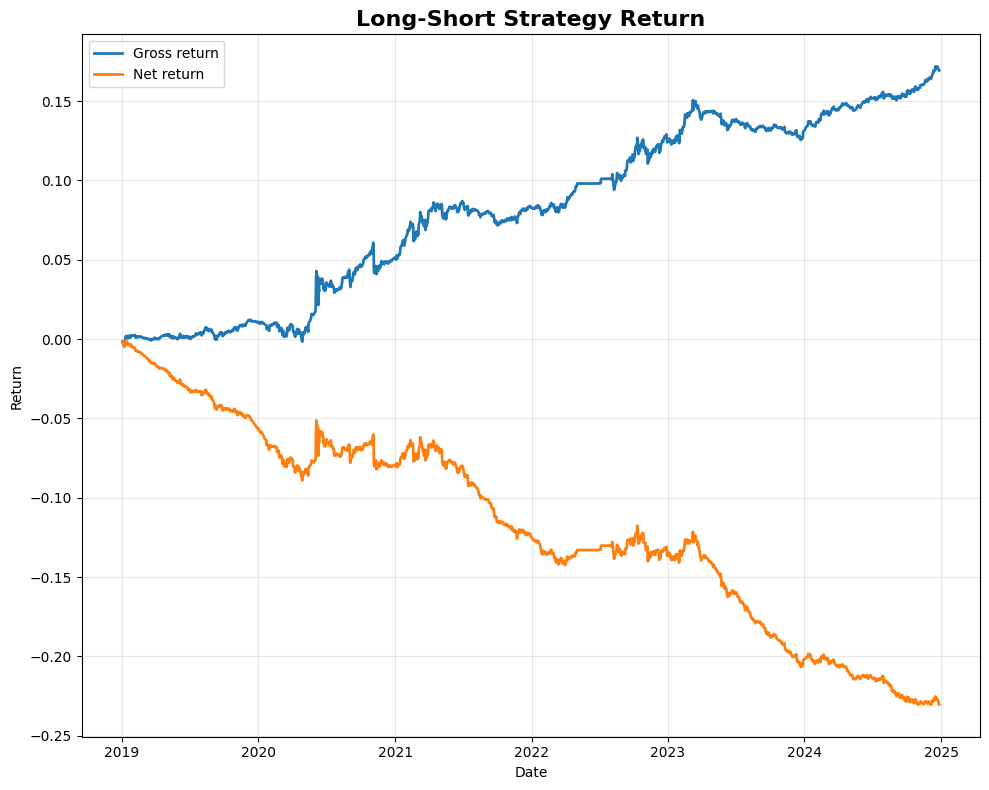

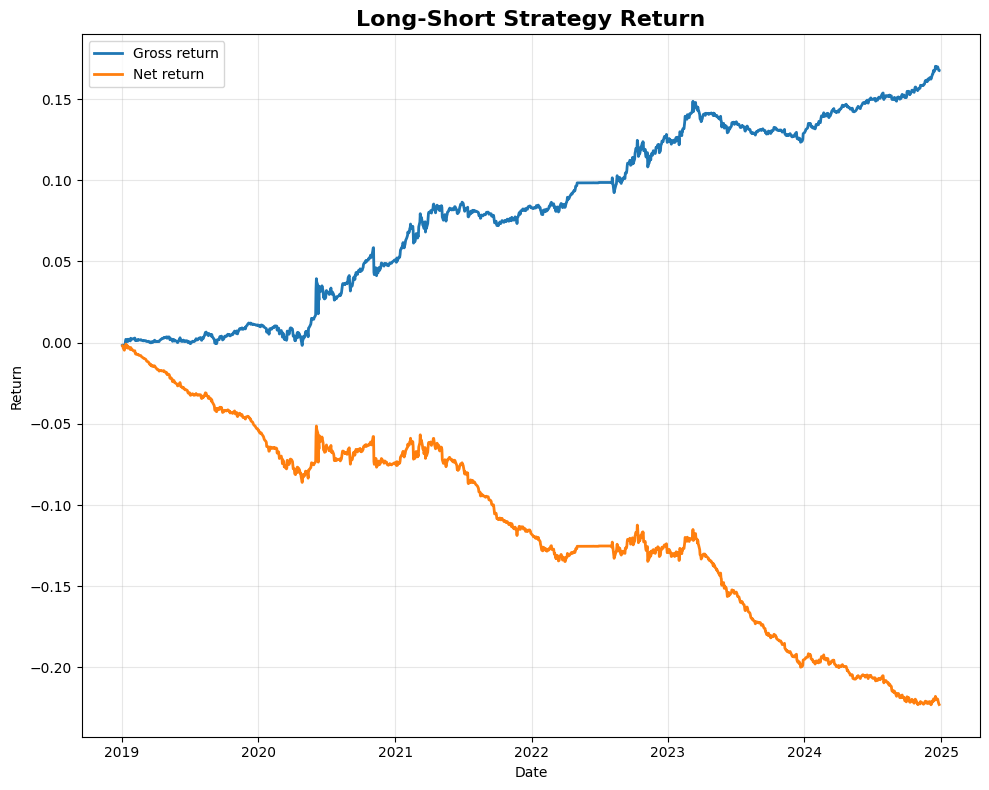

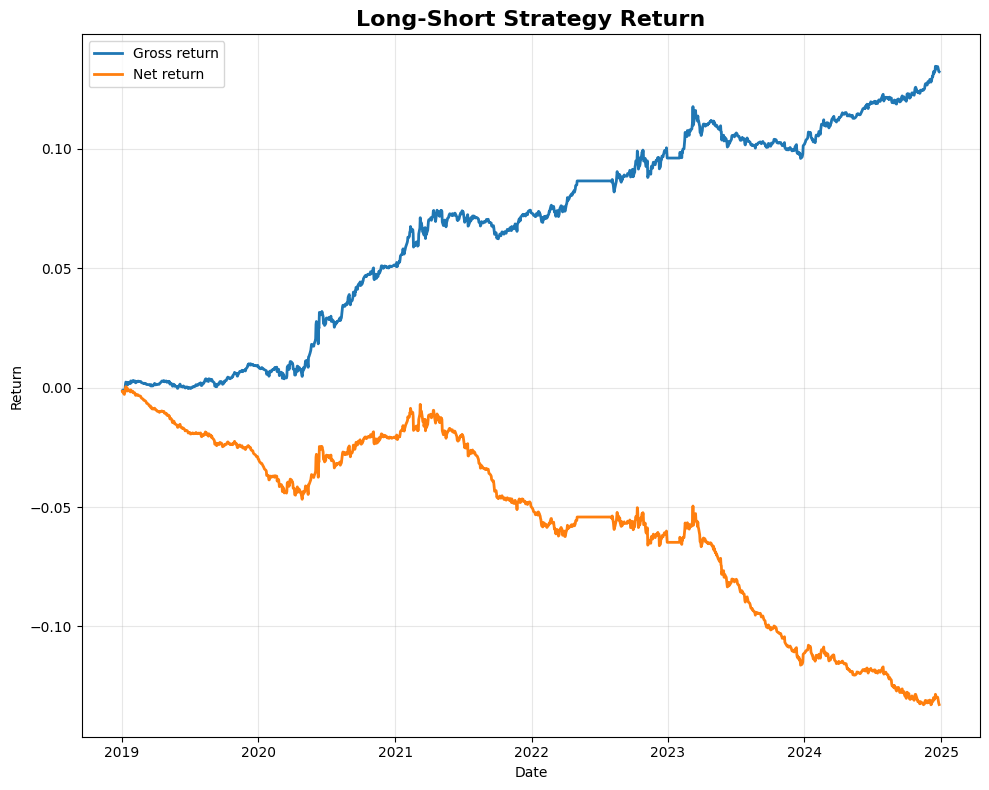

Basket sizes, fixed position size, exposure, and average daily turnover:


,aum_label,aum,position_per_stock,position_divisor,score_center_method,score_std_multiplier,max_names_per_side,avg_score_center,avg_long_score_threshold,avg_short_score_threshold,...,median_short_basket_size,avg_long_candidates,avg_short_candidates,avg_gross_exposure,avg_long_exposure,avg_short_exposure,avg_daily_turnover,median_daily_turnover,avg_daily_traded_dollar,n_trading_days
0,50m,50000000,125000.0,400.0,zero,1,200,0.0,0.020367,-0.020367,...,133.0,156.687666,147.943634,0.635468,0.317734,0.317734,0.635468,0.665,3.177338e+07,1508
1,250m,250000000,625000.0,400.0,zero,1,200,0.0,0.020397,-0.020397,...,131.0,154.414456,142.902520,0.620723,0.310361,0.310361,0.620723,0.655,1.551807e+08,1508
2,1b,1000000000,2500000.0,400.0,zero,1,200,0.0,0.020954,-0.020954,...,91.0,111.779841,97.155172,0.422304,0.211152,0.211152,0.422304,0.455,4.223044e+08,1508


Headline performance by AUM:


,aum_label,aum,position_per_stock,score_center_method,score_std_multiplier,max_names_per_side,gross_annualized_return,after_commission_annualized_return,after_slippage_annualized_return,net_annualized_return,...,after_slippage_annualized_volatility,net_annualized_volatility,gross_sharpe,after_commission_sharpe,after_slippage_sharpe,net_sharpe,gross_max_drawdown,after_commission_max_drawdown,after_slippage_max_drawdown,net_max_drawdown
0,50m,50000000,125000.0,zero,1,200,0.028301,0.012287,-0.035754,-0.038495,...,0.025189,0.025192,1.124940,0.488364,-1.419444,-1.528076,-0.021792,-0.036274,-0.213729,-0.229742
1,250m,250000000,625000.0,zero,1,200,0.028006,0.012363,-0.034563,-0.037241,...,0.024464,0.024467,1.145968,0.505894,-1.412850,-1.522137,-0.021961,-0.036295,-0.206709,-0.222319
2,1b,1000000000,2500000.0,zero,1,200,0.022103,0.011461,-0.020466,-0.022178,...,0.017007,0.017010,1.300719,0.674587,-1.203369,-1.303817,-0.019429,-0.030068,-0.123225,-0.133178


Gross-to-net Sharpe degradation by cost component:


,aum_label,aum,gross_sharpe,after_commission_sharpe,after_slippage_sharpe,net_sharpe,commission_sharpe_points,slippage_sharpe_points,borrow_sharpe_points,total_gross_to_net_sharpe_points,avg_daily_commission_cost_return,avg_daily_slippage_cost_return,avg_daily_borrow_cost_return,avg_daily_trading_cost_return,avg_daily_commission_cost_dollar,avg_daily_slippage_cost_dollar,avg_daily_borrow_cost_dollar,commission_bps,avg_slippage_bps,avg_total_trading_cost_bps
0,50m,50000000,1.124940,0.488364,-1.419444,-1.528076,0.636576,1.907808,0.108631,2.653016,0.000064,0.000191,0.000011,0.000254,3177.337533,9532.012599,543.820523,1.0,3.0,4.0
1,250m,250000000,1.145968,0.505894,-1.412850,-1.522137,0.640075,1.918743,0.109288,2.668106,0.000062,0.000186,0.000011,0.000248,15518.070292,46554.210875,2656.881552,1.0,3.0,4.0
2,1b,1000000000,1.300719,0.674587,-1.203369,-1.303817,0.626132,1.877956,0.100448,2.604536,0.000042,0.000127,0.000007,0.000169,42230.437666,126691.312997,6793.661320,1.0,3.0,4.0


In [50]:
eligibility_by_aum = {
    "50m": eligibility_50m,
    "250m": eligibility_250m,
    "1b": eligibility_1b,
}

aum_values = {
    "50m": 50_000_000,
    "250m": 250_000_000,
    "1b": 1_000_000_000,
}

import warnings
warnings.simplefilter("ignore", FutureWarning)

# Section 6.3 assumptions.
commission_bps_assumption = 1.0
total_trading_cost_bps_override = 4.0
position_divisor = 400.0
score_center_method = "zero" 
score_std_multiplier = 1
max_names_per_side = 200
backtest_start_date = f"{OOS_START_YEAR}-01-01"
backtest_end_date = f"{CUT_OUT_YEAR}-12-31"

signal_by_aum = {}
daily_ret_by_aum = {}
performance_by_aum = {}
sharpe_degradation_by_aum = {}
basket_stats_by_aum = {}

for aum_label, eligibility_df in eligibility_by_aum.items():
    signal_df, daily_ret, performance_table, degradation_table, basket_stats = run_backtest_for_one_aum(
        predictions=predictions_rf_cls,
        eligibility_df=eligibility_df,
        df_hardtoborrow=df_hardtoborrow,
        aum_label=aum_label,
        aum=aum_values[aum_label],
        position_divisor=position_divisor,
        score_center_method=score_center_method,
        score_std_multiplier=score_std_multiplier,
        max_names_per_side=max_names_per_side,
        figure_dir="figures",
        commission_bps=commission_bps_assumption,
        total_trading_cost_bps_override=total_trading_cost_bps_override,
        start_date=backtest_start_date,
        end_date=backtest_end_date,
    )

    signal_by_aum[aum_label] = signal_df
    daily_ret_by_aum[aum_label] = daily_ret
    performance_by_aum[aum_label] = performance_table
    sharpe_degradation_by_aum[aum_label] = degradation_table
    basket_stats_by_aum[aum_label] = basket_stats

performance_summary = pd.concat(
    performance_by_aum.values(),
    axis=0,
)

sharpe_degradation_summary = pd.concat(
    sharpe_degradation_by_aum.values(),
    axis=0,
    ignore_index=True,
)

basket_stats_summary = pd.concat(
    basket_stats_by_aum.values(),
    axis=0,
    ignore_index=True,
)

headline_performance_rows = []
for aum_label, perf in performance_by_aum.items():
    row = {
        "aum_label": aum_label,
        "aum": aum_values[aum_label],
        "position_per_stock": aum_values[aum_label] / position_divisor,
        "score_center_method": score_center_method,
        "score_std_multiplier": score_std_multiplier,
        "max_names_per_side": max_names_per_side,
    }

    for metric_name in ["annualized_return", "annualized_volatility", "sharpe", "max_drawdown"]:
        if metric_name in perf.index:
            for stage in ["gross", "after_commission", "after_slippage", "net"]:
                row[f"{stage}_{metric_name}"] = perf.loc[metric_name, stage]

    headline_performance_rows.append(row)

headline_performance_table = pd.DataFrame(headline_performance_rows)

from pathlib import Path
Path("prediction").mkdir(parents=True, exist_ok=True)
performance_summary.to_csv("prediction/rf_cls_performance_summary_by_aum.csv")
headline_performance_table.to_csv("prediction/rf_cls_headline_performance_by_aum.csv", index=False)
sharpe_degradation_summary.to_csv("prediction/rf_cls_sharpe_degradation_by_aum.csv", index=False)
basket_stats_summary.to_csv("prediction/rf_cls_basket_turnover_by_aum.csv", index=False)

print("Basket sizes, fixed position size, exposure, and average daily turnover:")
display(basket_stats_summary)

print("Headline performance by AUM:")
display(headline_performance_table)

print("Gross-to-net Sharpe degradation by cost component:")
display(sharpe_degradation_summary)


In [48]:
basket_stats_summary[['aum_label', 'position_per_stock',
       'avg_score_center', 'avg_long_score_threshold',
       'avg_short_score_threshold', 'avg_daily_score_mean',
       'avg_daily_score_median', 'avg_daily_score_std', 'avg_long_basket_size',
       'avg_short_basket_size', 'median_long_basket_size',
       'median_short_basket_size', 'avg_long_candidates',
       'avg_short_candidates', 'avg_gross_exposure', 'avg_long_exposure',
       'avg_short_exposure', 'avg_daily_turnover', 'median_daily_turnover',
       'avg_daily_traded_dollar']]

,aum_label,position_per_stock,avg_score_center,avg_long_score_threshold,avg_short_score_threshold,avg_daily_score_mean,avg_daily_score_median,avg_daily_score_std,avg_long_basket_size,avg_short_basket_size,median_long_basket_size,median_short_basket_size,avg_long_candidates,avg_short_candidates,avg_gross_exposure,avg_long_exposure,avg_short_exposure,avg_daily_turnover,median_daily_turnover,avg_daily_traded_dollar
0,50m,125000.0,0.0,0.020367,-0.020367,-0.000061,-0.000724,0.020367,127.093501,127.093501,133.0,133.0,156.687666,147.943634,0.635468,0.317734,0.317734,0.635468,0.665,3.177338e+07
1,250m,625000.0,0.0,0.020397,-0.020397,0.000015,-0.000665,0.020397,124.144562,124.144562,131.0,131.0,154.414456,142.902520,0.620723,0.310361,0.310361,0.620723,0.655,1.551807e+08
2,1b,2500000.0,0.0,0.020954,-0.020954,0.000176,-0.000647,0.020954,84.460875,84.460875,91.0,91.0,111.779841,97.155172,0.422304,0.211152,0.211152,0.422304,0.455,4.223044e+08


## 6-4 QuantStats tear-sheet for the 250M strategy

Generate a QuantStats HTML tear-sheet for the 250M net strategy return, benchmarked against `SP500_TR` using the already prepared `sp_ret_1` benchmark return. The report is restricted to the 2010-2024 window and saved as an HTML file for submission.


In [60]:
# QuantStats HTML tear-sheet for the 250M strategy benchmarked against SP500_TR.
# Strategy return: daily_ret_by_aum["250m"]["portfolio_return_net"]
# Benchmark return: sp500["sp_ret_1"]

from pathlib import Path

try:
    import quantstats as qs
except ImportError as exc:
    raise ImportError(
        "QuantStats is required for this tear-sheet. Install it with `pip install quantstats` "
        "in the notebook environment, then rerun this cell."
    ) from exc

Path("reports").mkdir(parents=True, exist_ok=True)
Path("prediction").mkdir(parents=True, exist_ok=True)

# -----------------------------
# 1. Prepare 250M strategy returns
# -----------------------------
strategy_250m = daily_ret_by_aum["250m"].copy()
strategy_250m["date"] = pd.to_datetime(strategy_250m["date"]).dt.normalize()

strategy_returns = (
    strategy_250m
    .set_index("date")["portfolio_return_gross"]
    .sort_index()
    .astype(float)
)

# -----------------------------
# 2. Prepare SP500_TR benchmark returns
# -----------------------------
benchmark_returns = sp500.copy()
benchmark_returns["date"] = pd.to_datetime(benchmark_returns["date"]).dt.normalize()

benchmark_returns = (
    benchmark_returns
    .set_index("date")["sp_ret_1"]
    .sort_index()
    .astype(float)
)

# -----------------------------
# 3. Restrict to the coursework window and align dates
# -----------------------------
start_date = pd.Timestamp(f"{OOS_START_YEAR}-01-01")
end_date = pd.Timestamp(f"{CUT_OUT_YEAR}-12-31")

strategy_returns = strategy_returns.loc[
    (strategy_returns.index >= start_date)
    & (strategy_returns.index <= end_date)
].dropna()

benchmark_returns = benchmark_returns.loc[
    (benchmark_returns.index >= start_date)
    & (benchmark_returns.index <= end_date)
].dropna()

tear_sheet_input = pd.concat(
    [
        strategy_returns.rename("strategy_250m_net"),
        benchmark_returns.rename("SP500_TR"),
    ],
    axis=1,
    join="inner",
).dropna()

if tear_sheet_input.empty:
    raise ValueError(
        "No overlapping strategy and SP500_TR benchmark returns are available "
        "inside the 2010-2024 window."
    )

strategy_qs = tear_sheet_input["strategy_250m_net"]
benchmark_qs = tear_sheet_input["SP500_TR"]

# QuantStats works best with timezone-naive datetime indexes.
strategy_qs.index = pd.to_datetime(strategy_qs.index).tz_localize(None)
benchmark_qs.index = pd.to_datetime(benchmark_qs.index).tz_localize(None)

# -----------------------------
# 4. Save aligned inputs and generate HTML tear-sheet
# -----------------------------
tear_sheet_input.to_csv("prediction/GROSS_250m_strategy_vs_sp500_inputs.csv")

quantstats_html_path = "reports/GROSS_250m_strategy_vs_sp500.html"

qs.reports.html(
    returns=strategy_qs,
    benchmark=benchmark_qs,
    title="250M RF Strategy (GROSS) vs SP500_TR",
    output=quantstats_html_path,
    download_filename=quantstats_html_path,
)

print(f"QuantStats tear-sheet saved to: {quantstats_html_path}")
print(f"Aligned return window: {tear_sheet_input.index.min().date()} to {tear_sheet_input.index.max().date()}")
print(f"Number of aligned return days: {len(tear_sheet_input)}")




# QuantStats HTML tear-sheet for the 250M strategy benchmarked against SP500_TR.
# Strategy return: daily_ret_by_aum["250m"]["portfolio_return_net"]
# Benchmark return: sp500["sp_ret_1"]

from pathlib import Path

try:
    import quantstats as qs
except ImportError as exc:
    raise ImportError(
        "QuantStats is required for this tear-sheet. Install it with `pip install quantstats` "
        "in the notebook environment, then rerun this cell."
    ) from exc

Path("reports").mkdir(parents=True, exist_ok=True)
Path("prediction").mkdir(parents=True, exist_ok=True)

# -----------------------------
# 1. Prepare 250M strategy returns
# -----------------------------
strategy_250m = daily_ret_by_aum["250m"].copy()
strategy_250m["date"] = pd.to_datetime(strategy_250m["date"]).dt.normalize()

strategy_returns = (
    strategy_250m
    .set_index("date")["portfolio_return_net"]
    .sort_index()
    .astype(float)
)

# -----------------------------
# 2. Prepare SP500_TR benchmark returns
# -----------------------------
benchmark_returns = sp500.copy()
benchmark_returns["date"] = pd.to_datetime(benchmark_returns["date"]).dt.normalize()

benchmark_returns = (
    benchmark_returns
    .set_index("date")["sp_ret_1"]
    .sort_index()
    .astype(float)
)

# -----------------------------
# 3. Restrict to the coursework window and align dates
# -----------------------------
start_date = pd.Timestamp(f"{OOS_START_YEAR}-01-01")
end_date = pd.Timestamp(f"{CUT_OUT_YEAR}-12-31")

strategy_returns = strategy_returns.loc[
    (strategy_returns.index >= start_date)
    & (strategy_returns.index <= end_date)
].dropna()

benchmark_returns = benchmark_returns.loc[
    (benchmark_returns.index >= start_date)
    & (benchmark_returns.index <= end_date)
].dropna()

tear_sheet_input = pd.concat(
    [
        strategy_returns.rename("strategy_250m_net"),
        benchmark_returns.rename("SP500_TR"),
    ],
    axis=1,
    join="inner",
).dropna()

if tear_sheet_input.empty:
    raise ValueError(
        "No overlapping strategy and SP500_TR benchmark returns are available "
        "inside the 2010-2024 window."
    )

strategy_qs = tear_sheet_input["strategy_250m_net"]
benchmark_qs = tear_sheet_input["SP500_TR"]

# QuantStats works best with timezone-naive datetime indexes.
strategy_qs.index = pd.to_datetime(strategy_qs.index).tz_localize(None)
benchmark_qs.index = pd.to_datetime(benchmark_qs.index).tz_localize(None)

# -----------------------------
# 4. Save aligned inputs and generate HTML tear-sheet
# -----------------------------
tear_sheet_input.to_csv("prediction/NET_250m_strategy_vs_sp500_inputs.csv")

quantstats_html_path = "reports/NET_250m_strategy_vs_sp500.html"

qs.reports.html(
    returns=strategy_qs,
    benchmark=benchmark_qs,
    title="250M RF Strategy (NET) vs SP500_TR",
    output=quantstats_html_path,
    download_filename=quantstats_html_path,
)

print(f"QuantStats tear-sheet saved to: {quantstats_html_path}")
print(f"Aligned return window: {tear_sheet_input.index.min().date()} to {tear_sheet_input.index.max().date()}")
print(f"Number of aligned return days: {len(tear_sheet_input)}")



QuantStats tear-sheet saved to: reports/GROSS_250m_strategy_vs_sp500.html
Aligned return window: 2019-01-02 to 2024-12-27
Number of aligned return days: 1508
QuantStats tear-sheet saved to: reports/NET_250m_strategy_vs_sp500.html
Aligned return window: 2019-01-02 to 2024-12-27
Number of aligned return days: 1508


## 6-5 Stress-window analysis

Evaluate how the AUM-aware strategy behaves during market dislocations. The code below reports gross and net performance, cost drag, drawdown, turnover, and basket size for selected stress windows such as 2020 Q1 and the 2022 drawdown.


Stress-window summary:


,window,aum_label,n_days,portfolio_return_gross_total,portfolio_return_net_total,portfolio_return_gross_sharpe,portfolio_return_net_sharpe,gross_to_net_total_drag,gross_to_net_sharpe_drag,portfolio_return_net_max_drawdown,avg_daily_turnover,avg_long_basket_size,avg_short_basket_size,avg_daily_traded_dollar,avg_commission_cost,avg_slippage_cost,avg_borrow_cost
0,2020_Q1_COVID_shock,50m,62,-0.001912,-0.019172,-0.375801,-3.738082,0.017260,3.362281,-0.023844,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020_Q1_COVID_shock,250m,62,-0.002261,-0.019014,-0.462769,-3.859465,0.016753,3.396696,-0.023667,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020_Q1_COVID_shock,1b,62,0.001365,-0.009621,0.378214,-2.641146,0.010986,3.019360,-0.014042,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022_drawdown,50m,209,0.037333,-0.003924,1.959572,-0.206097,0.041258,2.165669,-0.016794,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022_drawdown,250m,209,0.035058,-0.005228,1.877672,-0.280321,0.040285,2.157993,-0.016389,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2022_drawdown,1b,209,0.022087,-0.007323,1.533271,-0.509895,0.029410,2.043166,-0.011955,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2023_banking_stress,50m,23,-0.004582,-0.012593,-1.413937,-3.888416,0.008011,2.474479,-0.017887,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2023_banking_stress,250m,23,-0.004806,-0.012803,-1.477480,-3.937937,0.007997,2.460457,-0.018109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2023_banking_stress,1b,23,-0.002331,-0.009339,-0.621200,-2.489188,0.007008,1.867988,-0.016917,NaN,NaN,NaN,NaN,NaN,NaN,NaN


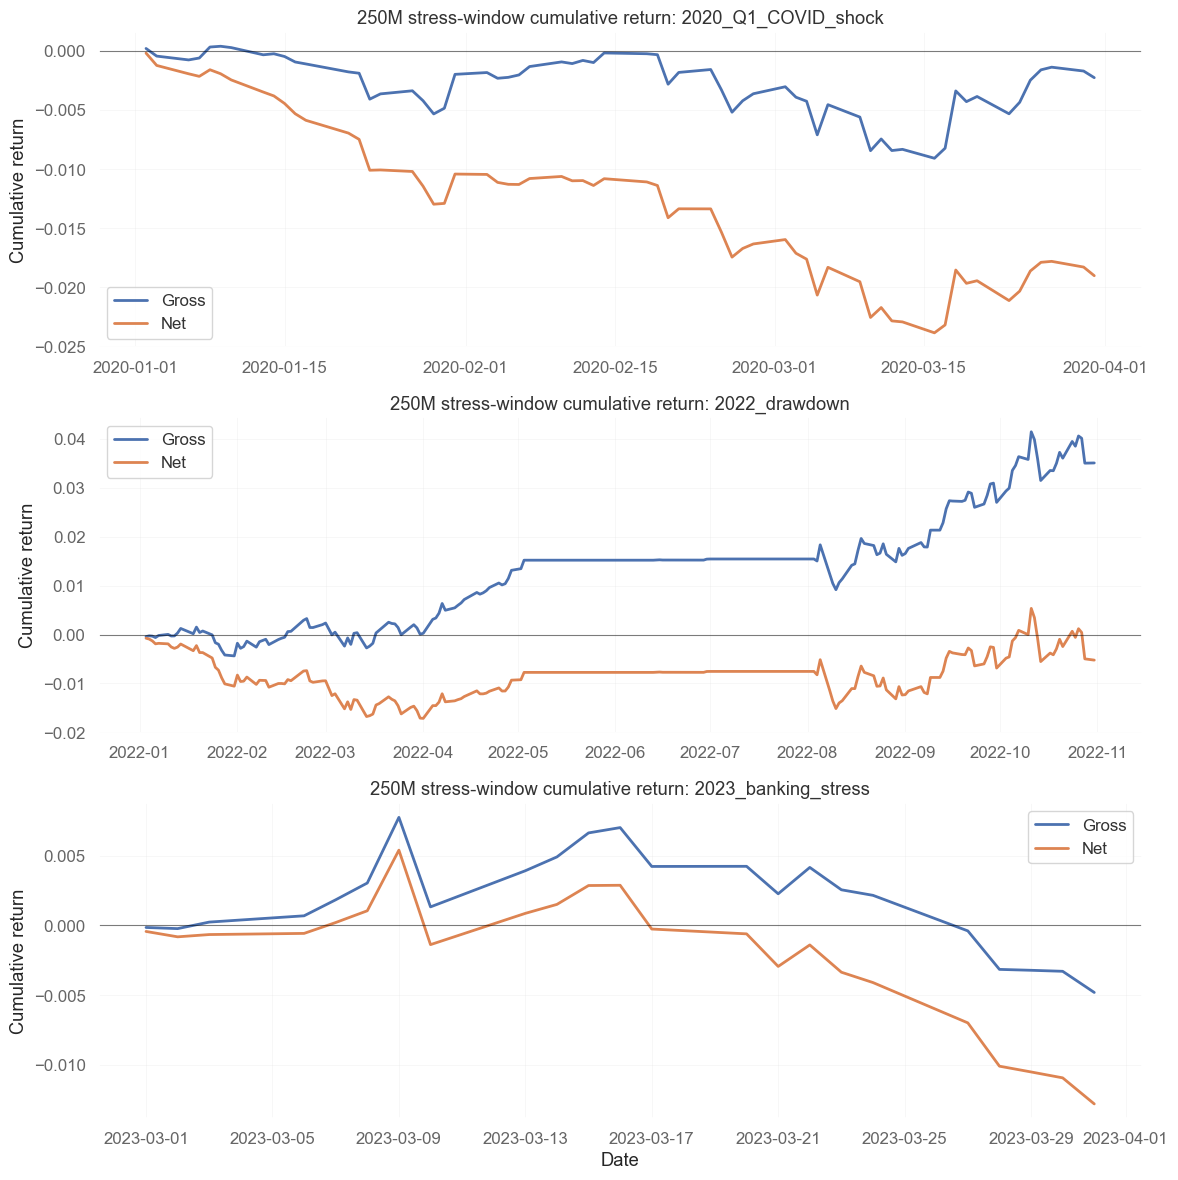

250M stress-window table for write-up:


,window,n_days,portfolio_return_gross_total,portfolio_return_net_total,portfolio_return_gross_sharpe,portfolio_return_net_sharpe,portfolio_return_net_max_drawdown,avg_daily_turnover
1,2020_Q1_COVID_shock,62,-0.002261,-0.019014,-0.462769,-3.859465,-0.023667,NaN
4,2022_drawdown,209,0.035058,-0.005228,1.877672,-0.280321,-0.016389,NaN
7,2023_banking_stress,23,-0.004806,-0.012803,-1.477480,-3.937937,-0.018109,NaN


\begin{tabular}{lrrrrrrr}
\toprule
window & n_days & portfolio_return_gross_total & portfolio_return_net_total & portfolio_return_gross_sharpe & portfolio_return_net_sharpe & portfolio_return_net_max_drawdown & avg_daily_turnover \\
\midrule
2020_Q1_COVID_shock & 62 & -0.0023 & -0.0190 & -0.4628 & -3.8595 & -0.0237 & NaN \\
2022_drawdown & 209 & 0.0351 & -0.0052 & 1.8777 & -0.2803 & -0.0164 & NaN \\
2023_banking_stress & 23 & -0.0048 & -0.0128 & -1.4775 & -3.9379 & -0.0181 & NaN \\
\bottomrule
\end{tabular}



In [61]:
# Stress-window analysis for market dislocations.
# This section uses the already built daily_ret_by_aum and basket_stats_by_aum objects.

from pathlib import Path
import matplotlib.pyplot as plt

Path("prediction").mkdir(parents=True, exist_ok=True)
Path("figures").mkdir(parents=True, exist_ok=True)

stress_windows = {
    "2020_Q1_COVID_shock": ("2020-01-01", "2020-03-31"),
    "2022_drawdown": ("2022-01-01", "2022-10-31"),
    "2023_banking_stress": ("2023-03-01", "2023-03-31"),
}

stress_return_cols = [
    "portfolio_return_gross",
    "portfolio_return_after_commission",
    "portfolio_return_after_slippage",
    "portfolio_return_net",
]


def summarize_stress_window(
    daily_ret: pd.DataFrame,
    window_name: str,
    start_date: str,
    end_date: str,
    aum_label: str,
    periods_per_year: int = 252,
) -> dict:
    """Summarize one strategy return stream inside one stress window."""
    df = daily_ret.copy()
    df["date"] = pd.to_datetime(df["date"])
    start_ts = pd.Timestamp(start_date)
    end_ts = pd.Timestamp(end_date)
    df = df.loc[(df["date"] >= start_ts) & (df["date"] <= end_ts)].sort_values("date")

    row = {
        "window": window_name,
        "start_date": start_ts.date(),
        "end_date": end_ts.date(),
        "aum_label": aum_label,
        "n_days": len(df),
    }

    if df.empty:
        for col in stress_return_cols:
            row[f"{col}_total"] = np.nan
            row[f"{col}_ann_return"] = np.nan
            row[f"{col}_ann_vol"] = np.nan
            row[f"{col}_sharpe"] = np.nan
            row[f"{col}_max_drawdown"] = np.nan
        row.update({
            "gross_to_net_total_drag": np.nan,
            "gross_to_net_sharpe_drag": np.nan,
            "avg_daily_turnover": np.nan,
            "avg_long_basket_size": np.nan,
            "avg_short_basket_size": np.nan,
            "avg_daily_traded_dollar": np.nan,
            "avg_daily_commission_cost": np.nan,
            "avg_daily_slippage_cost": np.nan,
            "avg_daily_borrow_cost": np.nan,
        })
        return row

    for col in stress_return_cols:
        metrics = compute_performance_metrics(
            daily_return_df=df,
            return_col=col,
            date_col="date",
            periods_per_year=periods_per_year,
            use_simple_pnl=True,
        )
        row[f"{col}_total"] = metrics.get("total_return", np.nan)
        row[f"{col}_ann_return"] = metrics.get("annualized_return", np.nan)
        row[f"{col}_ann_vol"] = metrics.get("annualized_volatility", np.nan)
        row[f"{col}_sharpe"] = metrics.get("sharpe", np.nan)
        row[f"{col}_max_drawdown"] = metrics.get("max_drawdown", np.nan)

    row["gross_to_net_total_drag"] = row["portfolio_return_gross_total"] - row["portfolio_return_net_total"]
    row["gross_to_net_sharpe_drag"] = row["portfolio_return_gross_sharpe"] - row["portfolio_return_net_sharpe"]

    for col in [
        "daily_turnover",
        "long_basket_size",
        "short_basket_size",
        "daily_traded_dollar",
        "commission_cost",
        "slippage_cost",
        "borrow_cost",
    ]:
        if col in df.columns:
            row[f"avg_{col}"] = pd.to_numeric(df[col], errors="coerce").mean()
        else:
            row[f"avg_{col}"] = np.nan

    return row


stress_rows = []

for window_name, (start_date, end_date) in stress_windows.items():
    for aum_label, daily_ret in daily_ret_by_aum.items():
        stress_rows.append(
            summarize_stress_window(
                daily_ret=daily_ret,
                window_name=window_name,
                start_date=start_date,
                end_date=end_date,
                aum_label=aum_label,
            )
        )

stress_window_summary = pd.DataFrame(stress_rows)
stress_window_summary.to_csv("prediction/rf_cls_stress_window_summary.csv", index=False)

stress_display_cols = [
    "window",
    "aum_label",
    "n_days",
    "portfolio_return_gross_total",
    "portfolio_return_net_total",
    "portfolio_return_gross_sharpe",
    "portfolio_return_net_sharpe",
    "gross_to_net_total_drag",
    "gross_to_net_sharpe_drag",
    "portfolio_return_net_max_drawdown",
    "avg_daily_turnover",
    "avg_long_basket_size",
    "avg_short_basket_size",
    "avg_daily_traded_dollar",
    "avg_commission_cost",
    "avg_slippage_cost",
    "avg_borrow_cost",
]

print("Stress-window summary:")
display(stress_window_summary[stress_display_cols])

# Plot gross and net cumulative returns for the primary 250M strategy in each stress window.
stress_plot_aum_label = "250m"
stress_plot_df = daily_ret_by_aum[stress_plot_aum_label].copy()
stress_plot_df["date"] = pd.to_datetime(stress_plot_df["date"])

fig, axes = plt.subplots(len(stress_windows), 1, figsize=(12, 4 * len(stress_windows)), sharex=False)
if len(stress_windows) == 1:
    axes = [axes]

for ax, (window_name, (start_date, end_date)) in zip(axes, stress_windows.items()):
    start_ts = pd.Timestamp(start_date)
    end_ts = pd.Timestamp(end_date)
    w = stress_plot_df.loc[
        (stress_plot_df["date"] >= start_ts)
        & (stress_plot_df["date"] <= end_ts)
    ].sort_values("date").copy()

    if w.empty:
        ax.set_title(f"{window_name}: no OOS data")
        ax.axis("off")
        continue

    w["stress_cum_gross"] = w["portfolio_return_gross"].fillna(0.0).cumsum()
    w["stress_cum_net"] = w["portfolio_return_net"].fillna(0.0).cumsum()

    ax.plot(w["date"], w["stress_cum_gross"], label="Gross", linewidth=2.0)
    ax.plot(w["date"], w["stress_cum_net"], label="Net", linewidth=2.0)
    ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
    ax.set_title(f"{stress_plot_aum_label.upper()} stress-window cumulative return: {window_name}")
    ax.set_ylabel("Cumulative return")
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.savefig(
    f"figures/rf_cls_{stress_plot_aum_label}_stress_window_cumulative_returns.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# Build a compact text table for the write-up.
stress_latex_table = stress_window_summary.loc[
    stress_window_summary["aum_label"].eq(stress_plot_aum_label),
    [
        "window",
        "n_days",
        "portfolio_return_gross_total",
        "portfolio_return_net_total",
        "portfolio_return_gross_sharpe",
        "portfolio_return_net_sharpe",
        "portfolio_return_net_max_drawdown",
        "avg_daily_turnover",
    ],
].copy()

print("250M stress-window table for write-up:")
display(stress_latex_table)
print(stress_latex_table.to_latex(index=False, float_format=lambda x: f"{x:.4f}"))
